<a href="https://colab.research.google.com/github/isocan/Pt111-MACE/blob/main/Pt111_H_coverage_differential_UMA_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pt(111) H* coverage screening with UMA/OC20-RPBE — v5

Changes relative to v4:

1. **Site classification is now purely geometric.** Each relaxed H is classified from the in-plane distances to the first, second, and third metal layers (ontop / bridge / three-fold hollow), and a hollow is called **hcp** only if a second-layer atom lies directly beneath it and **fcc** otherwise. Nothing depends on ASE's `adsorbate_info` catalogue any more.
2. **Figure titles say "top view" / "side view"** and carry the classified site(s). In v4 the string "— top" meant the *view direction*, not the adsorption site (the 1H minimum was `fcc_00`); v5 removes that ambiguity.
3. **1 ML (16H) is added** to the coverage series so that the Nørskov 0.25 ML and 1 ML Pt(111) values are both coverage-matched.
4. **A Nørskov-style 12-metal benchmark** rebuilds the 2×2, three-layer, 0.25 ML slabs of Nørskov *et al.* (2005) from the OC20 RPBE bulk records (`mp-81`, `mp-124`, …), relaxes H on every high-symmetry site with UMA, and compares against the Nørskov DFT, EquiformerV2, and single-point DFT columns of your table, with parity and volcano figures.

Coverage is still $\theta_\mathrm{H}=N_\mathrm{H}/16$ on the 4×4 slab: 1H = 0.0625 ML, 4H = 0.25 ML, 8H = 0.50 ML, 16H = 1.00 ML.

> UMA is used here as an RPBE-level screening model. Quantitative claims require recalculating the complete energy cycle — clean slab, every covered slab, and H₂ — with the same RPBE DFT settings.

## Energy definitions for sampled coverage steps

Let $E_N$ be the relaxed energy of the slab containing $N$ adsorbed H atoms and $E_\mathrm{H_2}$ the H₂ reference energy, all from the same electronic method.

$$\Delta E_\mathrm{cum}(N)=E_N-E_0-\frac{N}{2}E_\mathrm{H_2},\qquad \overline{\Delta E}_\mathrm{H}(N)=\frac{\Delta E_\mathrm{cum}(N)}{N}.$$

Sampled states are $N=0,1,4,8,16$. For a transition $N_a\to N_b$ with $\Delta N=N_b-N_a$,

$$\boxed{\Delta E_\mathrm{H}^{\mathrm{step}}(N_a\!\rightarrow\!N_b)=\frac{E_{N_b}-E_{N_a}-\frac{\Delta N}{2}E_\mathrm{H_2}}{\Delta N}}.$$

The notebook reports 0→1H, 1→4H, 4→8H, and 8→16H. Only 0→1H is a true single-H differential; the others are block differentials per added H. Thermochemistry:

$$\Delta G_\mathrm{H}^{\mathrm{step}}=\Delta E_\mathrm{H}^{\mathrm{step}}+\Delta\mathrm{ZPE}^{\mathrm{step}}-T\Delta S^{\mathrm{step}}.$$

Nørskov *et al.* report **average** energies at 0.25 ML and 1 ML; the 1 ML differential in their Eq. 15 is $2\,\overline{\Delta E}(1\,\mathrm{ML})-\overline{\Delta E}(0.25\,\mathrm{ML})$, which corresponds to our 0.25→1 ML block value $\frac{16\,\overline{\Delta E}(16)-4\,\overline{\Delta E}(4)}{12}$ only up to the different block width; both are tabulated.

## 0) Install the Colab/Kaggle environment

Select a GPU runtime. Run once per fresh session.

In [1]:
%pip -q install fairchem-core fairchem-data-oc ase pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.3/572.3 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.3/187.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.1/304.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 6.5 MB/s eta 0:00:00
   ━━━

### Optional Hugging Face authentication

Only if the UMA checkpoint returns a 401.

In [2]:
# from kaggle_secrets import UserSecretsClient
# from huggingface_hub import login
# login(token=UserSecretsClient().get_secret("HF_TOKEN"), add_to_git_credential=False)

## 1) Imports and reproducible settings

Every energy and geometry optimization uses `task_name="oc20"` (RPBE convention).

In [3]:
import copy
import itertools
import json
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ase.io as aseio
from IPython.display import display

from ase import Atoms
from ase.build import add_adsorbate, bulk as ase_bulk, fcc111, bcc110, hcp0001
from ase.constraints import FixAtoms
from ase.geometry import find_mic
from ase.optimize import BFGS
from ase.thermochemistry import HarmonicThermo, IdealGasThermo
from ase.vibrations import Vibrations
from ase.visualize.plot import plot_atoms

from fairchem.core import FAIRChemCalculator, pretrained_mlip
from fairchem.data.oc.core import Adsorbate, AdsorbateSlabConfig, Bulk, Slab
from fairchem.data.oc.core.multi_adsorbate_slab_config import MultipleAdsorbateSlabConfig
from fairchem.data.oc.utils import DetectTrajAnomaly

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

OUT_ROOT = Path("Pt111_H_4x4_UMA_RPBE_v5")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "uma-s-1p1"
TASK_NAME = "oc20"           # OC20 surface task; RPBE-trained
XC_LABEL = "RPBE"

OC20_PT_BULK_ID = "mp-126"  # RPBE-relaxed Pt record in the OC20 bulk database

SLAB_SIZE = (4, 4, 4)        # 16 Pt/layer × 4 layers = 64 Pt
VACUUM = 12.0                # Å on each side of centered slab
FIXED_BOTTOM_LAYERS = 2

FMAX = 0.05                  # eV/Å
MAX_STEPS = 220

COVERAGE_STATES_NH = (1, 4, 8, 16)   # 0.0625, 0.25, 0.50, 1.00 ML

TEMPERATURE_K = 298.15
H2_PRESSURE_PA = 100000.0    # 1 bar
VIB_DELTA_A = 0.02
VIB_NFREE = 2
IMAGINARY_MODE_TOL_EV = 0.005
MIN_REAL_MODE_EV = 0.001
RUN_VIBRATIONS = True

SITE_TYPES = ("fcc", "hcp", "bridge", "ontop")
H_HEIGHT = {"fcc": 0.95, "hcp": 0.95, "bridge": 1.15, "ontop": 1.55,
            "hollow": 1.00, "shortbridge": 1.15, "longbridge": 1.15}

# Geometric site classifier thresholds, in units of the surface nearest-neighbour distance.
ONTOP_TOL = 0.25      # H within 0.25 d_NN (in-plane) of a top-layer atom
HOLLOW_TOL = 0.72     # third-nearest top-layer atom within 0.72 d_NN  (ideal hollow: 0.577; ideal bridge: 0.866)
BRIDGE_TOL = 0.62     # second-nearest top-layer atom within 0.62 d_NN (ideal bridge: 0.5)
BELOW_TOL = 0.30      # sub-layer atom within 0.30 d_NN (in-plane) of the H → "directly beneath"
SUBSURFACE_DZ_A = 0.3 # H lower than top-layer mean z + 0.3 Å → subsurface

# AdsorbML/FairChem stochastic pools.
SINGLE_H_MODES = ("heuristic", "random_site_heuristic_placement", "random")
MULTI_H_MODES = ("random_site_heuristic_placement", "random")
RANDOM_NUM_SITES_1H = 32
RANDOM_NUM_SITES_MULTI = 160
RANDOM_NUM_CONFIGS_MULTI = 60
RANDOM_INTERSTITIAL_GAP_A = 0.35

# Explicit away-from-neighbour stream.
N_MIXED_MAXIMIN_SEEDS = 16
N_FAMILY_MAXIMIN_SEEDS = 4
MIN_HH_INITIAL_A = 1.15
MIN_HH_FINAL_A = 0.80

# Strategy-balanced relaxation quotas. Increase for production screening.
RELAX_QUOTAS = {
    1: {"manual_high_symmetry": 4, "fairchem_heuristic": 2,
        "fairchem_random_site_heuristic_placement": 3, "fairchem_random": 3},
    4: {"heuristic_maximin_separated": 6, "fairchem_random_site_heuristic_placement": 5, "fairchem_random": 5},
    8: {"heuristic_maximin_separated": 6, "fairchem_random_site_heuristic_placement": 5, "fairchem_random": 5},
    16: {"heuristic_maximin_separated": 6, "fairchem_random_site_heuristic_placement": 4, "fairchem_random": 4},
}

USE_ANOMALY_FILTER = True
SURFACE_CHANGE_CUTOFF_MULT = 1.5
DESORPTION_CUTOFF_MULT = 1.5

# Nørskov-style 12-metal benchmark (2×2, 3 layers, 1 H = 0.25 ML).
RUN_NORSKOV_SET = True
NORSKOV_SIZE = (2, 2, 3)
NORSKOV_FIXED_BOTTOM_LAYERS = 2   # only the top layer + H relax, as in Nørskov 2005
NORSKOV_VACUUM = 10.0

# RPBE validation export. The notebook writes VASP inputs but does not run VASP.
RPBE_ENCUT_EV = 450
RPBE_SURFACE_KMESH = (4, 4, 1)
RUN_RPBE_POSTPROCESS = False

# Third project element: state corrections from a solvent/electrolyte method.
RUN_SOLVENT_POSTPROCESS = False

## 2) Load UMA and obtain an RPBE-consistent Pt lattice constant

The Pt bulk geometry is read from the OC20 database record `mp-126` (RPBE-relaxed). For fcc, $a=(4V/N)^{1/3}$.

In [4]:
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

predictor = pretrained_mlip.get_predict_unit(MODEL_NAME, device=DEVICE)

def make_calc():
    return FAIRChemCalculator(predictor, task_name=TASK_NAME)

pt_bulk_record = Bulk(bulk_src_id_from_db=OC20_PT_BULK_ID)
pt_bulk_rpbe = pt_bulk_record.atoms.copy()
rpbe_bulk_dir = OUT_ROOT / "00_RPBE_bulk_lattice"
rpbe_bulk_dir.mkdir(parents=True, exist_ok=True)

volume_per_atom = float(pt_bulk_rpbe.get_volume() / len(pt_bulk_rpbe))
PT_LATTICE_A = float((4.0 * volume_per_atom) ** (1.0 / 3.0))

aseio.write(rpbe_bulk_dir / "Pt_bulk_OC20_RPBE.cif", pt_bulk_rpbe)
print(f"UMA model: {MODEL_NAME}; device: {DEVICE}")
print(f"Electronic convention: {TASK_NAME} / {XC_LABEL}")
print(f"Derived fcc a(Pt) = {PT_LATTICE_A:.5f} Å")
assert TASK_NAME == "oc20", "This benchmark is designed for the OC20/RPBE task."
assert pt_bulk_rpbe.get_chemical_formula().startswith("Pt"), "The selected bulk record is not Pt."

checkpoints/uma-s-1p1.pt: reconstructing file:   0%|          |  0.00B / 1.17GB            

checkpoints/uma-s-1p1.pt: downloading bytes:           |  0.00B            

iso_atom_elem_refs.yaml:   0%|          | 0.00/9.00k [00:00<?, ?B/s]

form_elem_refs.yaml:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

UMA model: uma-s-1p1; device: cuda
Electronic convention: oc20 / RPBE
Derived fcc a(Pt) = 3.98986 Å


## 3) Geometric adsorption-site classifier

The classifier uses only atomic positions and the `layer_id` array (1 = top layer). For each H it computes minimum-image in-plane distances $d$ to the top layer ($d^{(1)}_1\le d^{(1)}_2\le d^{(1)}_3$), and to the second and third layers, in units of the surface nearest-neighbour distance $d_\mathrm{NN}$:

| relaxed H site | $d^{(1)}_{1,2,3}/d_\mathrm{NN}$ (ideal) | beneath the site |
|---|---|---|
| ontop | 0, 1, 1 | – |
| bridge | 0.5, 0.5, 0.87 | – |
| three-fold hollow | 0.58, 0.58, 0.58 | **hcp**: second-layer atom directly below; **fcc**: no second-layer atom below (third-layer atom below for fcc(111)) |

An H that ends up below the top-layer plane is flagged `subsurface`. bcc(110) sites (ontop / short-bridge / long-bridge / quasi-three-fold hollow) are classified by the nearest ideal site of the top layer, which involves no sub-layer ambiguity.

In [5]:
def h_indices(atoms):
    return np.where(np.array(atoms.get_chemical_symbols()) == "H")[0]

def metal_indices_in_layer(atoms, layer):
    symbols = np.array(atoms.get_chemical_symbols())
    return np.where((symbols != "H") & (atoms.arrays["layer_id"] == layer))[0]

def xy_mic_vector(position_a, position_b, cell):
    vector = np.asarray(position_a) - np.asarray(position_b)
    vector_mic, _ = find_mic(np.asarray([vector]), cell, pbc=(True, True, False))
    return vector_mic[0]

def sorted_xy_distances(atoms, h_id, ids):
    if len(ids) == 0:
        return np.array([np.inf])
    vectors = atoms.positions[ids] - atoms.positions[int(h_id)]
    vectors_mic, _ = find_mic(vectors, atoms.cell, pbc=(True, True, False))
    return np.sort(np.linalg.norm(vectors_mic[:, :2], axis=1))

def surface_nn_distance(atoms):
    top = metal_indices_in_layer(atoms, 1)
    return min(atoms.get_distance(int(i), int(j), mic=True) for i, j in itertools.combinations(top, 2))

def classify_H_site_geometric(atoms, h_id, nn_distance=None):
    # Three-fold-hollow classifier for fcc(111) / hcp(0001) type layers.
    nn = surface_nn_distance(atoms) if nn_distance is None else nn_distance
    top_ids = metal_indices_in_layer(atoms, 1)
    d1 = sorted_xy_distances(atoms, h_id, top_ids) / nn
    d2 = sorted_xy_distances(atoms, h_id, metal_indices_in_layer(atoms, 2)) / nn
    d3 = sorted_xy_distances(atoms, h_id, metal_indices_in_layer(atoms, 3)) / nn
    height = float(atoms.positions[int(h_id), 2] - atoms.positions[top_ids, 2].mean())

    if height < SUBSURFACE_DZ_A:
        site = "subsurface"
    elif d1[0] < ONTOP_TOL:
        site = "ontop"
    elif len(d1) >= 3 and d1[2] < HOLLOW_TOL:
        site = "hcp" if d2[0] < BELOW_TOL else "fcc"
    elif len(d1) >= 2 and d1[1] < BRIDGE_TOL:
        site = "bridge"
    else:
        site = "off_site"
    return {
        "H_index": int(h_id), "site": site, "height_A": height,
        "d_top1_over_NN": float(d1[0]), "d_top2_over_NN": float(d1[1] if len(d1) > 1 else np.inf),
        "d_top3_over_NN": float(d1[2] if len(d1) > 2 else np.inf),
        "d_layer2_over_NN": float(d2[0]), "d_layer3_over_NN": float(d3[0]),
    }

def classify_H_site_by_catalogue(atoms, h_id, catalogue_positions, catalogue_labels, tol_A):
    vectors = catalogue_positions - atoms.positions[int(h_id)]
    vectors_mic, _ = find_mic(vectors, atoms.cell, pbc=(True, True, False))
    d_xy = np.linalg.norm(vectors_mic[:, :2], axis=1)
    nearest = int(np.argmin(d_xy))
    site = catalogue_labels[nearest] if float(d_xy[nearest]) <= tol_A else "off_site"
    return {"H_index": int(h_id), "site": site, "match_dxy_A": float(d_xy[nearest])}

def add_H_at_site(atoms, site_type, offset):
    before = len(atoms)
    add_adsorbate(atoms, "H", height=H_HEIGHT[site_type], position=site_type, offset=offset)
    tags = atoms.get_tags(); tags[before:] = 2; atoms.set_tags(tags)
    layer_ids = atoms.arrays["layer_id"].copy(); layer_ids[before:] = 0; atoms.set_array("layer_id", layer_ids)

def classify_relaxed_H_sites(atoms, site_types=SITE_TYPES):
    counts = {site: 0 for site in site_types}
    counts.update({"subsurface": 0, "off_site": 0})
    per_h = []
    nn = surface_nn_distance(atoms)
    for h_id in h_indices(atoms):
        row = classify_H_site_geometric(atoms, h_id, nn)
        counts[row["site"]] = counts.get(row["site"], 0) + 1
        per_h.append(row)
    return counts, per_h

def site_summary_string(counts):
    return " + ".join(f"{n}×{site}" for site, n in counts.items() if n > 0) or "clean"

# Self-test on an ideal fcc(111) slab: every ASE site label must be recovered.
_test = fcc111("Pt", size=(3, 3, 4), a=PT_LATTICE_A, vacuum=8.0, periodic=True)
_test.set_array("layer_id", _test.get_tags().copy())
for _site in SITE_TYPES:
    _probe = _test.copy()
    add_adsorbate(_probe, "H", height=H_HEIGHT[_site], position=_site)
    _layers = np.append(_probe.arrays["layer_id"][:-1], 0)
    _probe.set_array("layer_id", _layers)
    _got = classify_H_site_geometric(_probe, len(_probe) - 1)["site"]
    assert _got == _site, f"classifier self-test failed: placed {_site}, classified {_got}"
print("Geometric site classifier self-test passed (fcc, hcp, bridge, ontop).")

Geometric site classifier self-test passed (fcc, hcp, bridge, ontop).


## 4) Build and relax the 4×4 Pt(111) slab

The coverage denominator is asserted: 16 top-layer Pt atoms, 64 Pt total.

In [6]:
def fix_bottom_layers(atoms, n_layers, n_fixed):
    symbols = np.array(atoms.get_chemical_symbols())
    layers = atoms.arrays.get("layer_id")
    if layers is None:
        raise RuntimeError("Missing layer_id array; cannot define fixed layers safely.")
    first_fixed_layer = n_layers - n_fixed + 1
    frozen = np.where((symbols != "H") & (layers >= first_fixed_layer))[0]
    atoms.set_constraint(FixAtoms(indices=frozen.tolist()))

def constrain_lower_layers(atoms):
    fix_bottom_layers(atoms, SLAB_SIZE[2], FIXED_BOTTOM_LAYERS)

slab_initial = fcc111("Pt", size=SLAB_SIZE, a=PT_LATTICE_A, vacuum=VACUUM, orthogonal=False, periodic=True)
slab_initial.set_array("layer_id", slab_initial.get_tags().copy())
oc_tags = np.ones(len(slab_initial), dtype=int)
oc_tags[slab_initial.arrays["layer_id"] > (SLAB_SIZE[2] - FIXED_BOTTOM_LAYERS)] = 0
slab_initial.set_tags(oc_tags)
constrain_lower_layers(slab_initial)

top_layer = metal_indices_in_layer(slab_initial, 1)
N_SURFACE_PT = len(top_layer)

assert len(slab_initial) == 64, f"Expected 64 Pt atoms, found {len(slab_initial)}."
assert N_SURFACE_PT == 16, f"Expected 16 top-layer Pt atoms, found {N_SURFACE_PT}."
assert {n: n / N_SURFACE_PT for n in COVERAGE_STATES_NH} == {1: 0.0625, 4: 0.25, 8: 0.5, 16: 1.0}

def relax_atoms(atoms, trajectory_path, log_path, n_layers=None, n_fixed=None):
    atoms = atoms.copy()
    if n_layers is None:
        constrain_lower_layers(atoms)
    else:
        fix_bottom_layers(atoms, n_layers, n_fixed)
    atoms.calc = make_calc()
    optimizer = BFGS(atoms, trajectory=str(trajectory_path), logfile=str(log_path))
    converged = optimizer.run(fmax=FMAX, steps=MAX_STEPS)
    energy = float(atoms.get_potential_energy())
    max_force = float(np.linalg.norm(atoms.get_forces(), axis=1).max())
    return atoms, energy, bool(converged), max_force

clean_dir = OUT_ROOT / "01_clean_slab"
clean_dir.mkdir(parents=True, exist_ok=True)
slab_0, E_0, clean_converged, clean_max_force = relax_atoms(
    slab_initial, clean_dir / "clean_4x4.traj", clean_dir / "clean_4x4.log")
aseio.write(clean_dir / "POSCAR_clean_4x4.vasp", slab_0, format="vasp", direct=True, vasp5=True)
PT_SURFACE_NN_A = surface_nn_distance(slab_0)

print(f"Pt atoms = {len(slab_0)}; top-layer sites = {N_SURFACE_PT}; d_NN = {PT_SURFACE_NN_A:.3f} Å")
for n_h in COVERAGE_STATES_NH:
    print(f"{n_h:2d} H / {N_SURFACE_PT} sites = {n_h/N_SURFACE_PT:.4f} ML")
print(f"E(clean) = {E_0:.6f} eV; converged={clean_converged}; max|F|={clean_max_force:.4f} eV/Å")

W0904 11:40:20.817000 684 torch/_logging/_internal.py:1345] [0/0] Profiler record function <class 'torch.autograd.profiler.record_function'> will be ignored
W0904 11:40:27.855000 684 torch/_inductor/utils.py:1953] [3/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.13/dist-packages/torch/_inductor/lowering.py:2352: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(


Pt atoms = 64; top-layer sites = 16; d_NN = 2.821 Å
 1 H / 16 sites = 0.0625 ML
 4 H / 16 sites = 0.2500 ML
 8 H / 16 sites = 0.5000 ML
16 H / 16 sites = 1.0000 ML
E(clean) = -331.831912 eV; converged=True; max|F|=0.0226 eV/Å


## 5) H₂ reference with the same convention

Periodic box for UMA; a non-periodic copy is used later for `IdealGasThermo`.

In [7]:
reference_dir = OUT_ROOT / "02_H2_reference"
reference_dir.mkdir(parents=True, exist_ok=True)

h2_initial = Atoms("H2", positions=[[0.0, 0.0, 0.0], [0.0, 0.0, 0.74]])
h2_initial.center(vacuum=10.0)
h2_initial.set_pbc([True, True, True])
h2_initial.set_tags([2, 2])
h2_initial.calc = make_calc()
h2_opt = BFGS(h2_initial, trajectory=str(reference_dir / "H2.traj"), logfile=str(reference_dir / "H2.log"))
h2_converged = h2_opt.run(fmax=FMAX, steps=MAX_STEPS)
h2_relaxed = h2_initial
E_H2 = float(h2_relaxed.get_potential_energy())
E_H_REF = 0.5 * E_H2
h2_bond_A = h2_relaxed.get_distance(0, 1, mic=False)
aseio.write(reference_dir / "H2_UMA_periodic.xyz", h2_relaxed)
print(f"E(H2) = {E_H2:.6f} eV; 1/2 E(H2) = {E_H_REF:.6f} eV/H")
print(f"H-H bond = {h2_bond_A:.4f} Å; converged={bool(h2_converged)}")

Use inference_settings='batch' for heterogeneous batched evaluations.


E(H2) = -6.969667 eV; 1/2 E(H2) = -3.484834 eV/H
H-H bond = 0.7479 Å; converged=True


## 6) Candidate generation: heuristic, random-site heuristic, random, and separated

Single-H: FairChem `heuristic` + random modes + the four enumerated ideal sites. Multi-H (4H, 8H, 16H): greedy periodic **maximin** placement over site families (for 16H the pure fcc / hcp / ontop families fill the layer completely), FairChem `random_site_heuristic_placement`, and FairChem `random`.

In [8]:
def minimum_hh_distance(atoms):
    ids = h_indices(atoms)
    if len(ids) < 2:
        return np.inf
    return min(atoms.get_distance(int(i), int(j), mic=True) for i, j in itertools.combinations(ids, 2))

def minimum_hh_xy_distance(atoms):
    ids = h_indices(atoms)
    if len(ids) < 2:
        return np.inf
    return min(float(np.linalg.norm(xy_mic_vector(atoms.positions[i], atoms.positions[j], atoms.cell)[:2]))
               for i, j in itertools.combinations(ids, 2))

def separation_label(distance_xy):
    if not np.isfinite(distance_xy):
        return "single_H"
    ratio = distance_xy / PT_SURFACE_NN_A
    if ratio < 0.80:
        return "closer_than_Pt_NN"
    if ratio <= 1.20:
        return "near_Pt_NN"
    return "beyond_Pt_NN"

def normalize_generated_atoms(atoms, expected_n_h):
    atoms = atoms.copy()
    atoms.set_cell(slab_0.get_cell(), scale_atoms=False)
    atoms.set_pbc(True)
    symbols = np.array(atoms.get_chemical_symbols())
    pt_ids = np.where(symbols == "Pt")[0]
    h_ids = np.where(symbols == "H")[0]
    if len(pt_ids) != len(slab_0) or len(h_ids) != expected_n_h:
        raise ValueError(f"Expected {len(slab_0)} Pt + {expected_n_h} H; found {len(pt_ids)} Pt + {len(h_ids)} H.")
    layer_ids = np.zeros(len(atoms), dtype=int)
    layer_ids[pt_ids] = slab_0.arrays["layer_id"]
    atoms.set_array("layer_id", layer_ids)
    tags = np.ones(len(atoms), dtype=int)
    first_fixed_layer = SLAB_SIZE[2] - FIXED_BOTTOM_LAYERS + 1
    tags[pt_ids[layer_ids[pt_ids] >= first_fixed_layer]] = 0
    tags[h_ids] = 2
    atoms.set_tags(tags)
    constrain_lower_layers(atoms)
    return atoms

site_catalogue = []
for site_type in SITE_TYPES:
    for i in range(SLAB_SIZE[0]):
        for j in range(SLAB_SIZE[1]):
            probe = slab_0.copy()
            add_H_at_site(probe, site_type, (i, j))
            h_id = h_indices(probe)[-1]
            # Verify that the catalogue label agrees with the geometric classifier on the relaxed clean slab.
            geometric = classify_H_site_geometric(probe, h_id, PT_SURFACE_NN_A)["site"]
            assert geometric == site_type, f"catalogue/classifier mismatch at {site_type}_{i}{j}: {geometric}"
            site_catalogue.append({"site": site_type, "offset": (i, j), "label": f"{site_type}_{i}{j}",
                                   "position": probe.positions[h_id].copy()})
print(f"Site catalogue: {len(site_catalogue)} ideal sites; all labels verified geometrically.")

def candidate_record(atoms, n_h, label, strategy, generation_mode, site_seed):
    atoms = normalize_generated_atoms(atoms, expected_n_h=n_h)
    d_hh = minimum_hh_distance(atoms)
    d_hh_xy = minimum_hh_xy_distance(atoms)
    return {"N_H": n_h, "coverage_ML": n_h / N_SURFACE_PT, "label": label, "sampling_strategy": strategy,
            "generation_mode": generation_mode, "initial_site_seed": site_seed,
            "initial_min_HH_A": d_hh, "initial_min_HH_xy_A": d_hh_xy,
            "initial_HH_over_PtNN": d_hh_xy / PT_SURFACE_NN_A if np.isfinite(d_hh_xy) else np.nan,
            "initial_separation_class": separation_label(d_hh_xy), "atoms": atoms}

def make_manual_single_h_candidates():
    candidates = []
    for site_type in SITE_TYPES:
        entry = next(e for e in site_catalogue if e["site"] == site_type)
        atoms = slab_0.copy()
        add_H_at_site(atoms, entry["site"], entry["offset"])
        candidates.append(candidate_record(atoms, n_h=1, label=entry["label"], strategy="manual_high_symmetry",
                                           generation_mode="enumerated_fcc_hcp_bridge_ontop", site_seed=entry["site"]))
    return candidates

def greedy_maximin_entries(pool, n_h, seed_index):
    selected = [pool[seed_index % len(pool)]]
    remaining = [entry for entry in pool if entry["label"] != selected[0]["label"]]
    while len(selected) < n_h and remaining:
        def nearest_selected_distance(entry):
            return min(float(np.linalg.norm(xy_mic_vector(entry["position"], chosen["position"], slab_0.cell)[:2]))
                       for chosen in selected)
        next_entry = max(remaining, key=nearest_selected_distance)
        selected.append(next_entry)
        remaining = [entry for entry in remaining if entry["label"] != next_entry["label"]]
    return selected

def make_maximin_multi_candidates(n_h):
    selected_sets = []
    for site_type in SITE_TYPES:
        family = [entry for entry in site_catalogue if entry["site"] == site_type]
        if len(family) < n_h:
            continue
        for seed in range(N_FAMILY_MAXIMIN_SEEDS):
            selected_sets.append((f"{site_type}_family_seed{seed}", greedy_maximin_entries(family, n_h, seed)))
    for seed in range(N_MIXED_MAXIMIN_SEEDS):
        selected_sets.append((f"mixed_seed{seed}", greedy_maximin_entries(site_catalogue, n_h, seed)))

    def translational_fingerprint(selected):
        representations = []
        for shift_i in range(SLAB_SIZE[0]):
            for shift_j in range(SLAB_SIZE[1]):
                representations.append(tuple(sorted(
                    (entry["site"], (entry["offset"][0] - shift_i) % SLAB_SIZE[0], (entry["offset"][1] - shift_j) % SLAB_SIZE[1])
                    for entry in selected)))
        return min(representations)

    candidates, fingerprints = [], set()
    for seed_label, selected in selected_sets:
        if len(selected) != n_h:
            continue
        fingerprint = translational_fingerprint(selected)
        if fingerprint in fingerprints:
            continue
        fingerprints.add(fingerprint)
        atoms = slab_0.copy()
        for entry in selected:
            add_H_at_site(atoms, entry["site"], entry["offset"])
        record = candidate_record(atoms, n_h=n_h, label="__".join(sorted(entry["label"] for entry in selected)),
                                  strategy="heuristic_maximin_separated", generation_mode="greedy_periodic_maximin",
                                  site_seed=seed_label)
        if record["initial_min_HH_A"] >= MIN_HH_INITIAL_A:
            candidates.append(record)
    return candidates

def extract_atoms_from_metadata(meta):
    if not isinstance(meta, dict):
        return None
    for key in ("adsorbed_slab_atomsobject", "atoms", "atoms_object", "atoms_obj", "adslab", "adslab_atoms"):
        if key in meta:
            return meta[key]
    return None

def generated_atoms_list(generator, requested):
    if hasattr(generator, "atoms_list") and len(generator.atoms_list) > 0:
        return [atoms.copy() for atoms in generator.atoms_list[:requested]]
    out = []
    for index in range(requested):
        try:
            meta = generator.get_metadata_dict(index)
        except Exception:
            break
        atoms = extract_atoms_from_metadata(meta)
        if atoms is not None:
            out.append(atoms.copy())
    return out

pt_bulk_for_generator = Bulk(bulk_atoms=ase_bulk("Pt", "fcc", a=PT_LATTICE_A, cubic=True))
generator_slabs = Slab.from_bulk_get_specific_millers(bulk=pt_bulk_for_generator, specific_millers=(1, 1, 1))
if len(generator_slabs) == 0:
    raise RuntimeError("FairChem did not return a Pt(111) slab wrapper.")
generator_slab_template = generator_slabs[0]
adsorbate_H = Adsorbate(adsorbate_smiles_from_db="*H")

def make_generator_slab():
    wrapped = copy.deepcopy(generator_slab_template)
    wrapped.atoms = slab_0.copy()
    return wrapped

def make_fairchem_candidates(n_h, mode):
    strategy = f"fairchem_{mode}"
    try:
        if n_h == 1:
            generator = AdsorbateSlabConfig(make_generator_slab(), adsorbate_H, mode=mode, num_sites=RANDOM_NUM_SITES_1H)
            raw_atoms = generated_atoms_list(generator, RANDOM_NUM_SITES_1H)
        else:
            generator = MultipleAdsorbateSlabConfig(
                slab=make_generator_slab(), adsorbates=[adsorbate_H] * n_h, num_sites=RANDOM_NUM_SITES_MULTI,
                num_configurations=RANDOM_NUM_CONFIGS_MULTI, interstitial_gap=RANDOM_INTERSTITIAL_GAP_A, mode=mode)
            raw_atoms = generated_atoms_list(generator, RANDOM_NUM_CONFIGS_MULTI)
    except Exception as exc:
        print(f"WARNING: FairChem generator '{mode}' for {n_h}H failed: {exc}")
        return []
    candidates = []
    for index, atoms in enumerate(raw_atoms):
        try:
            record = candidate_record(atoms, n_h=n_h, label=f"{strategy}_{index:03d}", strategy=strategy,
                                      generation_mode=mode, site_seed="FairChem_surface_sample")
        except Exception as exc:
            print(f"  skipped {strategy} candidate {index}: {exc}")
            continue
        if record["initial_min_HH_A"] >= MIN_HH_INITIAL_A:
            candidates.append(record)
    return candidates

candidates_by_n = {1: make_manual_single_h_candidates()}
for mode in SINGLE_H_MODES:
    candidates_by_n[1].extend(make_fairchem_candidates(1, mode))
for n_h in COVERAGE_STATES_NH[1:]:
    candidates_by_n[n_h] = make_maximin_multi_candidates(n_h)
    for mode in MULTI_H_MODES:
        candidates_by_n[n_h].extend(make_fairchem_candidates(n_h, mode))
for n_h in COVERAGE_STATES_NH:
    if not candidates_by_n[n_h]:
        raise RuntimeError(f"No initial candidates were generated for {n_h}H.")

candidate_inventory = pd.DataFrame([{k: v for k, v in row.items() if k != "atoms"}
                                    for n_h in COVERAGE_STATES_NH for row in candidates_by_n[n_h]])
candidate_inventory.to_csv(OUT_ROOT / "generated_candidate_inventory.csv", index=False)
display(candidate_inventory.groupby(["N_H", "coverage_ML", "sampling_strategy"], dropna=False)
        .size().rename("generated_candidates").reset_index())

Site catalogue: 64 ideal sites; all labels verified geometrically.


,N_H,coverage_ML,sampling_strategy,generated_candidates
0,1,0.0625,fairchem_heuristic,10
1,1,0.0625,fairchem_random,32
2,1,0.0625,fairchem_random_site_heuristic_placement,32
3,1,0.0625,manual_high_symmetry,4
4,4,0.2500,fairchem_random,54
5,4,0.2500,fairchem_random_site_heuristic_placement,55
6,4,0.2500,heuristic_maximin_separated,6
7,8,0.5000,fairchem_random,38
8,8,0.5000,fairchem_random_site_heuristic_placement,37
9,8,0.5000,heuristic_maximin_separated,15


## 7) UMA prescreen, strategy-balanced relaxation, anomaly checks, and geometric site classification

In [9]:
def safe_name(label):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", label)[:120]

def single_point_screen(candidates):
    screened, t0 = [], time.time()
    for k, item in enumerate(candidates, start=1):
        atoms = item["atoms"].copy()
        atoms.calc = make_calc()
        screened.append({**item, "E_SP_UMA_eV": float(atoms.get_potential_energy())})
        if k % 25 == 0 or k == len(candidates):
            print(f"  screened {k}/{len(candidates)}")
    screened.sort(key=lambda row: row["E_SP_UMA_eV"])
    for rank, row in enumerate(screened, start=1):
        row["SP_global_rank"] = rank
    print(f"Single-point screening finished in {time.time()-t0:.1f} s")
    return screened

def select_by_strategy(screened, quotas):
    selected, selected_labels = [], set()
    for strategy, quota in quotas.items():
        group = [row for row in screened if row["sampling_strategy"] == strategy]
        for strategy_rank, row in enumerate(group[:quota], start=1):
            selected.append({**row, "strategy_SP_rank": strategy_rank})
            selected_labels.add((row["sampling_strategy"], row["label"]))
    target = min(sum(quotas.values()), len(screened))
    for row in screened:
        key = (row["sampling_strategy"], row["label"])
        if len(selected) >= target:
            break
        if key in selected_labels:
            continue
        selected.append({**row, "strategy_SP_rank": np.nan}); selected_labels.add(key)
    selected.sort(key=lambda row: row["E_SP_UMA_eV"])
    return selected

def trajectory_anomaly_flags(frames):
    if not USE_ANOMALY_FILTER:
        return []
    try:
        detector = DetectTrajAnomaly(frames[0], frames[-1], frames[0].get_tags(),
                                     surface_change_cutoff_multiplier=SURFACE_CHANGE_CUTOFF_MULT,
                                     desorption_cutoff_multiplier=DESORPTION_CUTOFF_MULT)
        checks = {"adsorbate_dissociated": detector.is_adsorbate_dissociated(),
                  "adsorbate_desorbed": detector.is_adsorbate_desorbed(),
                  "surface_changed": detector.has_surface_changed(),
                  "adsorbate_intercalated": detector.is_adsorbate_intercalated()}
        return [name for name, flagged in checks.items() if flagged]
    except Exception as exc:
        print(f"WARNING: anomaly detector failed ({type(exc).__name__}: {exc}); geometry checks continue.")
        return []

def relax_selected(selected):
    n_h = int(selected[0]["N_H"]); coverage = float(selected[0]["coverage_ML"])
    run_dir = OUT_ROOT / f"{n_h:02d}H_{coverage:.4f}ML"
    run_dir.mkdir(parents=True, exist_ok=True)
    accepted, rejected = [], []
    for relax_rank, item in enumerate(selected, start=1):
        stem = f"relax_{relax_rank:03d}_{safe_name(item['sampling_strategy'])}_{safe_name(item['label'])}"
        traj_path, log_path = run_dir / f"{stem}.traj", run_dir / f"{stem}.log"
        final_atoms, energy, converged, max_force = relax_atoms(item["atoms"], traj_path, log_path)
        frames = aseio.read(traj_path, ":")
        anomaly_flags = trajectory_anomaly_flags(frames)
        d_hh_final, d_hh_xy_final = minimum_hh_distance(final_atoms), minimum_hh_xy_distance(final_atoms)
        site_counts, site_details = classify_relaxed_H_sites(final_atoms)

        reject_reasons = []
        if not converged: reject_reasons.append("not_converged")
        if d_hh_final < MIN_HH_FINAL_A: reject_reasons.append("short_final_HH")
        if site_counts.get("subsurface", 0) > 0: reject_reasons.append("subsurface_H")
        reject_reasons.extend(anomaly_flags)

        common = {"N_H": n_h, "coverage_ML": coverage, "configuration": item["label"],
                  "sampling_strategy": item["sampling_strategy"], "generation_mode": item["generation_mode"],
                  "initial_site_seed": item["initial_site_seed"], "SP_global_rank": item["SP_global_rank"],
                  "strategy_SP_rank": item["strategy_SP_rank"], "E_SP_UMA_eV": item["E_SP_UMA_eV"],
                  "E_relaxed_UMA_eV": energy, "converged": converged, "max_force_eV_per_A": max_force,
                  "initial_min_HH_A": item["initial_min_HH_A"], "initial_min_HH_xy_A": item["initial_min_HH_xy_A"],
                  "initial_HH_over_PtNN": item["initial_HH_over_PtNN"],
                  "initial_separation_class": item["initial_separation_class"],
                  "final_min_HH_A": d_hh_final, "final_min_HH_xy_A": d_hh_xy_final,
                  "relaxed_site_summary": site_summary_string(site_counts),
                  "relaxed_site_counts_json": json.dumps(site_counts),
                  "relaxed_H_sites_json": json.dumps(site_details),
                  "trajectory": str(traj_path), "log_file": str(log_path)}
        if reject_reasons:
            rejected.append({**common, "status": "rejected", "rejection_reasons": ";".join(reject_reasons)})
            print(f"  REJECT {n_h}H | {item['sampling_strategy']} | {';'.join(reject_reasons)}")
            continue
        accepted.append({**common, "status": "accepted", "final_atoms": final_atoms})
        print(f"  ACCEPT {n_h:2d}H | E={energy:.6f} eV | {item['sampling_strategy']:<40s} | {site_summary_string(site_counts)}")
    accepted_df = pd.DataFrame(accepted)
    if len(accepted_df):
        accepted_df = accepted_df.sort_values("E_relaxed_UMA_eV").reset_index(drop=True)
    return accepted_df, pd.DataFrame(rejected)

def without_atoms(rows):
    return pd.DataFrame([{k: v for k, v in row.items() if k != "atoms"} for row in rows])

screened_by_n, selected_by_n, results_by_n, rejected_by_n = {}, {}, {}, {}
for n_h in COVERAGE_STATES_NH:
    print(f"\n=== {n_h}H ({n_h/N_SURFACE_PT:.4f} ML) ===")
    screened_by_n[n_h] = single_point_screen(candidates_by_n[n_h])
    selected_by_n[n_h] = select_by_strategy(screened_by_n[n_h], RELAX_QUOTAS[n_h])
    results_by_n[n_h], rejected_by_n[n_h] = relax_selected(selected_by_n[n_h])
    if len(results_by_n[n_h]) == 0:
        raise RuntimeError(f"No accepted relaxed minimum for {n_h}H; inspect trajectories and rejection table.")
    tag = f"{n_h:02d}H_{n_h/N_SURFACE_PT:.4f}ML"
    without_atoms(screened_by_n[n_h]).to_csv(OUT_ROOT / f"prescreened_all_{tag}.csv", index=False)
    without_atoms(selected_by_n[n_h]).to_csv(OUT_ROOT / f"selected_for_relaxation_{tag}.csv", index=False)
    results_by_n[n_h].drop(columns="final_atoms").to_csv(OUT_ROOT / f"accepted_relaxed_{tag}.csv", index=False)
    rejected_by_n[n_h].to_csv(OUT_ROOT / f"rejected_relaxed_{tag}.csv", index=False)

strategy_minima_rows = []
for n_h in COVERAGE_STATES_NH:
    results = results_by_n[n_h]
    coverage_minimum = float(results["E_relaxed_UMA_eV"].min())
    for strategy, group in results.groupby("sampling_strategy"):
        best = group.loc[group["E_relaxed_UMA_eV"].idxmin()]
        strategy_minima_rows.append({"N_H": n_h, "coverage_ML": n_h / N_SURFACE_PT, "sampling_strategy": strategy,
                                     "minimum_configuration": best["configuration"],
                                     "minimum_E_relaxed_UMA_eV": float(best["E_relaxed_UMA_eV"]),
                                     "energy_above_coverage_minimum_eV": float(best["E_relaxed_UMA_eV"]) - coverage_minimum,
                                     "final_min_HH_xy_A": float(best["final_min_HH_xy_A"]),
                                     "relaxed_site_summary": best["relaxed_site_summary"], "trajectory": best["trajectory"]})
strategy_minima_table = pd.DataFrame(strategy_minima_rows).sort_values(["N_H", "minimum_E_relaxed_UMA_eV"]).reset_index(drop=True)
strategy_minima_table.to_csv(OUT_ROOT / "minimum_by_sampling_strategy.csv", index=False)
display(strategy_minima_table.style.format({"coverage_ML": "{:.4f}", "minimum_E_relaxed_UMA_eV": "{:.6f}",
                                            "energy_above_coverage_minimum_eV": "{:+.4f}", "final_min_HH_xy_A": "{:.3f}"}))


=== 1H (0.0625 ML) ===
  screened 25/78
  screened 50/78
  screened 75/78
  screened 78/78
Single-point screening finished in 6.5 s
  ACCEPT  1H | E=-335.643954 eV | manual_high_symmetry                     | 1×ontop
  ACCEPT  1H | E=-335.655271 eV | manual_high_symmetry                     | 1×fcc
  ACCEPT  1H | E=-335.654288 eV | fairchem_random                          | 1×fcc
  ACCEPT  1H | E=-335.655171 eV | fairchem_random                          | 1×fcc
  ACCEPT  1H | E=-335.627793 eV | fairchem_random                          | 1×bridge
  ACCEPT  1H | E=-335.624234 eV | fairchem_heuristic                       | 1×bridge
  ACCEPT  1H | E=-335.614906 eV | manual_high_symmetry                     | 1×hcp
  ACCEPT  1H | E=-335.627168 eV | fairchem_random_site_heuristic_placement | 1×bridge
  ACCEPT  1H | E=-335.623446 eV | fairchem_heuristic                       | 1×bridge
  ACCEPT  1H | E=-335.624896 eV | manual_high_symmetry                     | 1×bridge
  ACCEPT  1H | E=-33

,N_H,coverage_ML,sampling_strategy,minimum_configuration,minimum_E_relaxed_UMA_eV,energy_above_coverage_minimum_eV,final_min_HH_xy_A,relaxed_site_summary,trajectory
0,1,0.0625,manual_high_symmetry,fcc_00,-335.655271,+0.0000,inf,1×fcc,Pt111_H_4x4_UMA_RPBE_v5/01H_0.0625ML/relax_002_manual_high_symmetry_fcc_00.traj
1,1,0.0625,fairchem_random,fairchem_random_031,-335.655171,+0.0001,inf,1×fcc,Pt111_H_4x4_UMA_RPBE_v5/01H_0.0625ML/relax_004_fairchem_random_fairchem_random_031.traj
2,1,0.0625,fairchem_random_site_heuristic_placement,fairchem_random_site_heuristic_placement_000,-335.627168,+0.0281,inf,1×bridge,Pt111_H_4x4_UMA_RPBE_v5/01H_0.0625ML/relax_008_fairchem_random_site_heuristic_placement_fairchem_random_site_heuristic_placement_000.traj
3,1,0.0625,fairchem_heuristic,fairchem_heuristic_006,-335.624234,+0.0310,inf,1×bridge,Pt111_H_4x4_UMA_RPBE_v5/01H_0.0625ML/relax_006_fairchem_heuristic_fairchem_heuristic_006.traj
4,4,0.2500,heuristic_maximin_separated,fcc_00__fcc_02__fcc_20__fcc_22,-347.076611,+0.0000,5.643,4×fcc,Pt111_H_4x4_UMA_RPBE_v5/04H_0.2500ML/relax_001_heuristic_maximin_separated_fcc_00__fcc_02__fcc_20__fcc_22.traj
5,4,0.2500,fairchem_random_site_heuristic_placement,fairchem_random_site_heuristic_placement_030,-347.043495,+0.0331,2.857,3×fcc + 1×ontop,Pt111_H_4x4_UMA_RPBE_v5/04H_0.2500ML/relax_008_fairchem_random_site_heuristic_placement_fairchem_random_site_heuristic_placement_030.traj
6,4,0.2500,fairchem_random,fairchem_random_002,-346.978530,+0.0981,3.018,1×fcc + 2×bridge + 1×ontop,Pt111_H_4x4_UMA_RPBE_v5/04H_0.2500ML/relax_014_fairchem_random_fairchem_random_002.traj
7,8,0.5000,heuristic_maximin_separated,fcc_00__fcc_01__fcc_03__fcc_11__fcc_12__fcc_21__fcc_23__fcc_32,-362.036706,+0.0000,2.820,8×fcc,Pt111_H_4x4_UMA_RPBE_v5/08H_0.5000ML/relax_001_heuristic_maximin_separated_fcc_00__fcc_01__fcc_03__fcc_11__fcc_12__fcc_21__fcc_23__fcc_32.traj
8,8,0.5000,fairchem_random_site_heuristic_placement,fairchem_random_site_heuristic_placement_040,-361.972016,+0.0647,2.540,3×fcc + 3×bridge + 2×ontop,Pt111_H_4x4_UMA_RPBE_v5/08H_0.5000ML/relax_011_fairchem_random_site_heuristic_placement_fairchem_random_site_heuristic_placement_040.traj
9,8,0.5000,fairchem_random,fairchem_random_017,-361.799347,+0.2374,2.115,1×fcc + 3×hcp + 3×bridge + 1×ontop,Pt111_H_4x4_UMA_RPBE_v5/08H_0.5000ML/relax_014_fairchem_random_fairchem_random_017.traj


## 8) Select minima and calculate electronic adsorption energies

In [10]:
minima = {0: {"N_H": 0, "coverage_ML": 0.0, "configuration": "clean", "sampling_strategy": "reference",
              "site_summary": "clean", "energy_eV": E_0, "atoms": slab_0}}
for n_h in COVERAGE_STATES_NH:
    best = results_by_n[n_h].iloc[0]
    minima[n_h] = {"N_H": n_h, "coverage_ML": n_h / N_SURFACE_PT, "configuration": best["configuration"],
                   "sampling_strategy": best["sampling_strategy"], "site_summary": best["relaxed_site_summary"],
                   "energy_eV": float(best["E_relaxed_UMA_eV"]), "atoms": best["final_atoms"]}

sampled_states = (0,) + tuple(COVERAGE_STATES_NH)
energy_rows = []
for previous_n, n_h in zip(sampled_states[:-1], sampled_states[1:]):
    delta_n = n_h - previous_n
    e_n, e_previous = minima[n_h]["energy_eV"], minima[previous_n]["energy_eV"]
    cumulative = e_n - E_0 - n_h * E_H_REF
    step_total = e_n - e_previous - delta_n * E_H_REF
    energy_rows.append({"N_H_previous": previous_n, "N_H": n_h, "delta_N_H": delta_n,
                        "coverage_previous_ML": previous_n / N_SURFACE_PT, "coverage_ML": n_h / N_SURFACE_PT,
                        "transition": f"{previous_n}H* -> {n_h}H*", "minimum_configuration": minima[n_h]["configuration"],
                        "minimum_site_summary": minima[n_h]["site_summary"],
                        "minimum_sampling_strategy": minima[n_h]["sampling_strategy"], "E_NH_UMA_eV": e_n,
                        "E_H_ref_eV": E_H_REF, "delta_E_H_cumulative_eV": cumulative,
                        "delta_E_H_average_eV_per_H": cumulative / n_h, "delta_E_H_step_total_eV": step_total,
                        "delta_E_H_step_eV_per_H": step_total / delta_n})
energy_table = pd.DataFrame(energy_rows)
energy_table.to_csv(OUT_ROOT / "electronic_adsorption_energy_summary.csv", index=False)

assert np.isclose(energy_table["delta_E_H_step_total_eV"].sum(), energy_table.iloc[-1]["delta_E_H_cumulative_eV"])
weighted_average = np.average(energy_table["delta_E_H_step_eV_per_H"], weights=energy_table["delta_N_H"])
assert np.isclose(weighted_average, energy_table.iloc[-1]["delta_E_H_average_eV_per_H"])

display(energy_table.drop(columns=["minimum_configuration"]).style.format({
    "coverage_previous_ML": "{:.4f}", "coverage_ML": "{:.4f}", "E_NH_UMA_eV": "{:.6f}", "E_H_ref_eV": "{:.6f}",
    "delta_E_H_cumulative_eV": "{:.4f}", "delta_E_H_average_eV_per_H": "{:.4f}",
    "delta_E_H_step_total_eV": "{:.4f}", "delta_E_H_step_eV_per_H": "{:.4f}"}))
print("Energy-cycle checks passed.")

,N_H_previous,N_H,delta_N_H,coverage_previous_ML,coverage_ML,transition,minimum_site_summary,minimum_sampling_strategy,E_NH_UMA_eV,E_H_ref_eV,delta_E_H_cumulative_eV,delta_E_H_average_eV_per_H,delta_E_H_step_total_eV,delta_E_H_step_eV_per_H
0,0,1,1,0.0000,0.0625,0H* -> 1H*,1×fcc,manual_high_symmetry,-335.655271,-3.484834,-0.3385,-0.3385,-0.3385,-0.3385
1,1,4,3,0.0625,0.2500,1H* -> 4H*,4×fcc,heuristic_maximin_separated,-347.076611,-3.484834,-1.3054,-0.3263,-0.9668,-0.3223
2,4,8,4,0.2500,0.5000,4H* -> 8H*,8×fcc,heuristic_maximin_separated,-362.036706,-3.484834,-2.3261,-0.2908,-1.0208,-0.2552
3,8,16,8,0.5000,1.0000,8H* -> 16H*,16×fcc,heuristic_maximin_separated,-391.394442,-3.484834,-3.8052,-0.2378,-1.4791,-0.1849


Energy-cycle checks passed.


## 9) Coverage-specific vibrational modes

Only H atoms are displaced; Pt phonons are assumed to cancel. 16H needs 96 finite-difference evaluations.

In [11]:
vibration_dir = OUT_ROOT / "vibrations"
vibration_dir.mkdir(parents=True, exist_ok=True)

def validated_real_modes(raw_energies, label, keep_highest=None):
    raw = np.asarray(raw_energies, dtype=complex)
    significant_imag = np.abs(raw.imag) > IMAGINARY_MODE_TOL_EV
    if np.any(significant_imag):
        raise RuntimeError(f"{label}: significant imaginary vibrational energies {raw[significant_imag]}.")
    modes = np.sort(raw.real[raw.real > MIN_REAL_MODE_EV])
    if keep_highest is not None:
        if len(modes) < keep_highest:
            raise RuntimeError(f"{label}: found {len(modes)} positive modes; expected {keep_highest}.")
        modes = modes[-keep_highest:]
    if len(modes) == 0:
        raise RuntimeError(f"{label}: no usable positive vibrational modes.")
    print(f"{label}: retained {len(modes)} mode(s); min={modes.min():.4f} eV, max={modes.max():.4f} eV")
    return modes

def calculate_vibrations(atoms, indices, label, keep_highest=None):
    atoms_vib = atoms.copy()
    if "Pt" in atoms_vib.get_chemical_symbols():
        constrain_lower_layers(atoms_vib)
    atoms_vib.calc = make_calc()
    state_dir = vibration_dir / label
    state_dir.mkdir(parents=True, exist_ok=True)
    vib = Vibrations(atoms_vib, indices=[int(i) for i in indices], name=str(state_dir / "vib"),
                     delta=VIB_DELTA_A, nfree=VIB_NFREE)
    vib.clean(); vib.run()
    raw = np.asarray(vib.get_energies(), dtype=complex)
    pd.DataFrame({"mode": np.arange(1, len(raw) + 1), "energy_real_eV": raw.real,
                  "energy_imag_eV": raw.imag}).to_csv(state_dir / "raw_vibrational_energies.csv", index=False)
    modes = validated_real_modes(raw, label=label, keep_highest=keep_highest)
    vib.clean()
    return modes

ads_modes, h2_modes = {}, None
if RUN_VIBRATIONS:
    for n_h in COVERAGE_STATES_NH:
        atoms_n = minima[n_h]["atoms"]
        h_ids = h_indices(atoms_n)
        assert len(h_ids) == n_h
        ads_modes[n_h] = calculate_vibrations(atoms_n, h_ids, label=f"state_{n_h}H")
    h2_modes = calculate_vibrations(h2_relaxed, [0, 1], label="H2", keep_highest=1)
else:
    print("Vibrations skipped. Electronic adsorption-energy tables remain available.")

state_1H: retained 3 mode(s); min=0.0723 eV, max=0.1240 eV
state_4H: retained 12 mode(s); min=0.0697 eV, max=0.1237 eV
state_8H: retained 24 mode(s); min=0.0634 eV, max=0.1264 eV
state_16H: retained 48 mode(s); min=0.0664 eV, max=0.1289 eV
H2: retained 1 mode(s); min=0.5314 eV, max=0.5314 eV


## 10) ZPE, entropy, and ΔG

In [12]:
if RUN_VIBRATIONS:
    zpe_state_eV, entropy_state_eV_per_K = {0: 0.0}, {0: 0.0}
    for n_h in COVERAGE_STATES_NH:
        modes = ads_modes[n_h]
        zpe_state_eV[n_h] = 0.5 * float(np.sum(modes))
        entropy_state_eV_per_K[n_h] = float(HarmonicThermo(vib_energies=modes, potentialenergy=0.0)
                                            .get_entropy(TEMPERATURE_K, verbose=False))
    zpe_H2_eV = 0.5 * float(np.sum(h2_modes))
    h2_thermo_atoms = h2_relaxed.copy(); h2_thermo_atoms.set_pbc(False)
    h2_thermo = IdealGasThermo(vib_energies=h2_modes, potentialenergy=0.0, atoms=h2_thermo_atoms,
                               geometry="linear", symmetrynumber=2, spin=0)
    entropy_H2_eV_per_K = float(h2_thermo.get_entropy(temperature=TEMPERATURE_K, pressure=H2_PRESSURE_PA, verbose=False))

    state_thermo_rows = [{"state": "clean", "N_H": 0, "ZPE_eV": 0.0, "entropy_eV_per_K": 0.0, "entropy_model": "Pt phonons cancelled"}]
    for n_h in COVERAGE_STATES_NH:
        state_thermo_rows.append({"state": f"{n_h}H*", "N_H": n_h, "ZPE_eV": zpe_state_eV[n_h],
                                  "entropy_eV_per_K": entropy_state_eV_per_K[n_h],
                                  "entropy_model": f"coupled modes of {n_h} adsorbed H"})
    state_thermo_rows.append({"state": "H2(g)", "N_H": 2, "ZPE_eV": zpe_H2_eV, "entropy_eV_per_K": entropy_H2_eV_per_K,
                              "entropy_model": "ideal-gas translation+rotation+vibration"})
    pd.DataFrame(state_thermo_rows).to_csv(OUT_ROOT / "state_ZPE_entropy_summary.csv", index=False)

    free_energy_rows, cumulative_delta_G = [], 0.0
    for _, energy_row in energy_table.iterrows():
        previous_n, n_h, delta_n = int(energy_row["N_H_previous"]), int(energy_row["N_H"]), int(energy_row["delta_N_H"])
        delta_E_per_H = float(energy_row["delta_E_H_step_eV_per_H"])
        delta_ZPE_per_H = (zpe_state_eV[n_h] - zpe_state_eV[previous_n] - 0.5 * delta_n * zpe_H2_eV) / delta_n
        delta_S_per_H = (entropy_state_eV_per_K[n_h] - entropy_state_eV_per_K[previous_n]
                         - 0.5 * delta_n * entropy_H2_eV_per_K) / delta_n
        minus_T_delta_S_per_H = -TEMPERATURE_K * delta_S_per_H
        delta_G_per_H = delta_E_per_H + delta_ZPE_per_H + minus_T_delta_S_per_H
        cumulative_delta_G += delta_G_per_H * delta_n
        free_energy_rows.append({"N_H_previous": previous_n, "N_H": n_h, "delta_N_H": delta_n,
                                 "coverage_previous_ML": previous_n / N_SURFACE_PT, "coverage_ML": n_h / N_SURFACE_PT,
                                 "transition": f"{previous_n}H* -> {n_h}H*", "temperature_K": TEMPERATURE_K,
                                 "H2_pressure_Pa": H2_PRESSURE_PA, "delta_E_H_step_eV_per_H": delta_E_per_H,
                                 "delta_ZPE_step_eV_per_H": delta_ZPE_per_H, "delta_S_step_eV_per_K_per_H": delta_S_per_H,
                                 "minus_T_delta_S_step_eV_per_H": minus_T_delta_S_per_H,
                                 "delta_G_H_step_eV_per_H": delta_G_per_H, "delta_G_H_step_total_eV": delta_G_per_H * delta_n,
                                 "delta_G_H_cumulative_eV": cumulative_delta_G,
                                 "delta_G_H_average_eV_per_H": cumulative_delta_G / n_h})
    free_energy_table = pd.DataFrame(free_energy_rows)
    free_energy_table.to_csv(OUT_ROOT / "H_free_energy_summary.csv", index=False)
    print(f"Thermochemistry: T={TEMPERATURE_K:.2f} K; p(H2)={H2_PRESSURE_PA:.0f} Pa")
    print(f"ZPE(H2)={zpe_H2_eV:.4f} eV; S(H2)={entropy_H2_eV_per_K:.6e} eV/K")
    display(free_energy_table.style.format({
        "coverage_previous_ML": "{:.4f}", "coverage_ML": "{:.4f}", "delta_E_H_step_eV_per_H": "{:.4f}",
        "delta_ZPE_step_eV_per_H": "{:+.4f}", "delta_S_step_eV_per_K_per_H": "{:+.6e}",
        "minus_T_delta_S_step_eV_per_H": "{:+.4f}", "delta_G_H_step_eV_per_H": "{:.4f}",
        "delta_G_H_step_total_eV": "{:.4f}", "delta_G_H_cumulative_eV": "{:.4f}", "delta_G_H_average_eV_per_H": "{:.4f}"}))
else:
    free_energy_table = None
    print("ΔG table not created because RUN_VIBRATIONS=False.")

Thermochemistry: T=298.15 K; p(H2)=100000 Pa
ZPE(H2)=0.2657 eV; S(H2)=1.352364e-03 eV/K


,N_H_previous,N_H,delta_N_H,coverage_previous_ML,coverage_ML,transition,temperature_K,H2_pressure_Pa,delta_E_H_step_eV_per_H,delta_ZPE_step_eV_per_H,delta_S_step_eV_per_K_per_H,minus_T_delta_S_step_eV_per_H,delta_G_H_step_eV_per_H,delta_G_H_step_total_eV,delta_G_H_cumulative_eV,delta_G_H_average_eV_per_H
0,0,1,1,0.0000,0.0625,0H* -> 1H*,298.150000,100000.000000,-0.3385,+0.0015,-6.305816e-04,+0.1880,-0.1490,-0.1490,-0.1490,-0.1490
1,1,4,3,0.0625,0.2500,1H* -> 4H*,298.150000,100000.000000,-0.3223,-0.0021,-6.267154e-04,+0.1869,-0.1375,-0.4125,-0.5615,-0.1404
2,4,8,4,0.2500,0.5000,4H* -> 8H*,298.150000,100000.000000,-0.2552,+0.0056,-6.335455e-04,+0.1889,-0.0607,-0.2430,-0.8045,-0.1006
3,8,16,8,0.5000,1.0000,8H* -> 16H*,298.150000,100000.000000,-0.1849,+0.0073,-6.334544e-04,+0.1889,0.0113,0.0905,-0.7140,-0.0446


## 11) Solvent/electrolyte correction interface

OC20 represents solid–gas adsorption. State-level $G_\mathrm{solv}(N)$ values from OC25/eSEN, explicit-water DFT, or implicit solvation are entered through the template and enter as

$$\Delta G_\mathrm{solv}^{\mathrm{step}}=\frac{G_\mathrm{solv}(N_b)-G_\mathrm{solv}(N_a)}{N_b-N_a}.$$

In [13]:
solvent_template_path = OUT_ROOT / "solvent_state_correction_template.csv"
solvent_template = pd.DataFrame({
    "state": ["clean"] + [f"{n}H" for n in COVERAGE_STATES_NH],
    "N_H": list(sampled_states),
    "coverage_ML": [n / N_SURFACE_PT for n in sampled_states],
    "G_solv_state_eV": [np.nan] * len(sampled_states),
    "recommended_source": ["OC25/eSEN or solvent DFT"] + ["same method as clean"] * len(COVERAGE_STATES_NH)})
if not solvent_template_path.exists():
    solvent_template.to_csv(solvent_template_path, index=False)
display(solvent_template)

if RUN_SOLVENT_POSTPROCESS:
    if free_energy_table is None:
        raise RuntimeError("Run the vibrational thermochemistry before adding solvent corrections.")
    solvent_input = pd.read_csv(solvent_template_path)
    if solvent_input["G_solv_state_eV"].isna().any():
        raise ValueError(f"Missing solvent state corrections for: "
                         f"{solvent_input.loc[solvent_input['G_solv_state_eV'].isna(), 'state'].tolist()}")
    g_solv = dict(zip(solvent_input["N_H"].astype(int), solvent_input["G_solv_state_eV"]))
    interface_rows = []
    for _, row in free_energy_table.iterrows():
        n_a, n_b, delta_n = int(row["N_H_previous"]), int(row["N_H"]), int(row["delta_N_H"])
        delta_g_solv = (float(g_solv[n_b]) - float(g_solv[n_a])) / delta_n
        interface_rows.append({"transition": row["transition"], "coverage_ML": row["coverage_ML"],
                               "delta_G_vacuum_eV_per_H": row["delta_G_H_step_eV_per_H"],
                               "delta_G_solv_eV_per_H": delta_g_solv,
                               "delta_G_interface_eV_per_H": row["delta_G_H_step_eV_per_H"] + delta_g_solv})
    interface_free_energy_table = pd.DataFrame(interface_rows)
    interface_free_energy_table.to_csv(OUT_ROOT / "H_free_energy_with_solvent.csv", index=False)
    display(interface_free_energy_table)
else:
    interface_free_energy_table = None
    print("Solvent post-processing is off; the template is ready for OC25/eSEN or solvent-DFT values.")

,state,N_H,coverage_ML,G_solv_state_eV,recommended_source
0,clean,0,0.0000,NaN,OC25/eSEN or solvent DFT
1,1H,1,0.0625,NaN,same method as clean
2,4H,4,0.2500,NaN,same method as clean
3,8H,8,0.5000,NaN,same method as clean
4,16H,16,1.0000,NaN,same method as clean


Solvent post-processing is off; the template is ready for OC25/eSEN or solvent-DFT values.


## 12) Export selected minima and consistent RPBE-DFT inputs

`GGA = RP` selects RPBE in VASP; use one PAW-PBE potential set for every state. Never mix DFT and UMA total energies in one cycle.

In [14]:
export_dir = OUT_ROOT / "RPBE_DFT_validation"
export_dir.mkdir(parents=True, exist_ok=True)

surface_lines = ["SYSTEM = Pt111_H_coverage_RPBE", "GGA = RP", f"ENCUT = {RPBE_ENCUT_EV}", "PREC = Accurate",
                 "EDIFF = 1E-6", "EDIFFG = -0.03", "IBRION = 2", "NSW = 250", "ISIF = 2", "ISMEAR = 1", "SIGMA = 0.20",
                 "LREAL = Auto", "LASPH = .TRUE.", "LDIPOL = .TRUE.", "IDIPOL = 3", "LWAVE = .FALSE.", "LCHARG = .FALSE."]
h2_lines = ["SYSTEM = H2_RPBE_reference", "GGA = RP", f"ENCUT = {RPBE_ENCUT_EV}", "PREC = Accurate", "EDIFF = 1E-7",
            "EDIFFG = -0.01", "IBRION = 2", "NSW = 120", "ISIF = 2", "ISMEAR = 0", "SIGMA = 0.05", "LREAL = .FALSE.",
            "LASPH = .TRUE.", "LWAVE = .FALSE.", "LCHARG = .FALSE."]
surface_incar = "\n".join(surface_lines) + "\n"
h2_incar = "\n".join(h2_lines) + "\n"

def kpoints_text(mesh):
    return "Automatic mesh\n0\nGamma\n{} {} {}\n0 0 0\n".format(*mesh)

export_rows = []
for n_h in sampled_states:
    state = minima[n_h]
    state_dir = export_dir / f"{n_h:02d}H_{state['coverage_ML']:.4f}ML"
    state_dir.mkdir(parents=True, exist_ok=True)
    aseio.write(state_dir / "POSCAR", state["atoms"], format="vasp", direct=True, vasp5=True)
    (state_dir / "INCAR").write_text(surface_incar)
    (state_dir / "KPOINTS").write_text(kpoints_text(RPBE_SURFACE_KMESH))
    export_rows.append({"state": "clean" if n_h == 0 else f"{n_h}H", "N_H": n_h, "coverage_ML": state["coverage_ML"],
                        "site_summary": state["site_summary"], "sampling_strategy": state["sampling_strategy"],
                        "UMA_oc20_energy_eV": state["energy_eV"], "RPBE_directory": str(state_dir),
                        "RPBE_total_energy_eV": np.nan})

h2_rpbe_atoms = h2_relaxed.copy(); h2_rpbe_atoms.set_pbc(True); h2_rpbe_atoms.center(vacuum=10.0)
h2_rpbe_dir = export_dir / "H2_reference"; h2_rpbe_dir.mkdir(parents=True, exist_ok=True)
aseio.write(h2_rpbe_dir / "POSCAR", h2_rpbe_atoms, format="vasp", direct=True, vasp5=True)
(h2_rpbe_dir / "INCAR").write_text(h2_incar)
(h2_rpbe_dir / "KPOINTS").write_text(kpoints_text((1, 1, 1)))
export_rows.append({"state": "H2", "N_H": 2, "coverage_ML": np.nan, "site_summary": "gas_reference",
                    "sampling_strategy": "reference", "UMA_oc20_energy_eV": E_H2,
                    "RPBE_directory": str(h2_rpbe_dir), "RPBE_total_energy_eV": np.nan})
export_table = pd.DataFrame(export_rows)
rpbe_template_path = export_dir / "rpbe_energy_template.csv"
export_table.to_csv(rpbe_template_path, index=False)
display(export_table)
print(f"Fill RPBE energies in: {rpbe_template_path}")

,state,N_H,coverage_ML,site_summary,sampling_strategy,UMA_oc20_energy_eV,RPBE_directory,RPBE_total_energy_eV
0,clean,0,0.0000,clean,reference,-331.831912,Pt111_H_4x4_UMA_RPBE_v5/RPBE_DFT_validation/00...,NaN
1,1H,1,0.0625,1×fcc,manual_high_symmetry,-335.655271,Pt111_H_4x4_UMA_RPBE_v5/RPBE_DFT_validation/01...,NaN
2,4H,4,0.2500,4×fcc,heuristic_maximin_separated,-347.076611,Pt111_H_4x4_UMA_RPBE_v5/RPBE_DFT_validation/04...,NaN
3,8H,8,0.5000,8×fcc,heuristic_maximin_separated,-362.036706,Pt111_H_4x4_UMA_RPBE_v5/RPBE_DFT_validation/08...,NaN
4,16H,16,1.0000,16×fcc,heuristic_maximin_separated,-391.394442,Pt111_H_4x4_UMA_RPBE_v5/RPBE_DFT_validation/16...,NaN
5,H2,2,NaN,gas_reference,reference,-6.969667,Pt111_H_4x4_UMA_RPBE_v5/RPBE_DFT_validation/H2...,NaN


Fill RPBE energies in: Pt111_H_4x4_UMA_RPBE_v5/RPBE_DFT_validation/rpbe_energy_template.csv


### Optional RPBE-DFT post-processing

After filling the template, set `RUN_RPBE_POSTPROCESS=True` and rerun.

In [15]:
if RUN_RPBE_POSTPROCESS:
    rpbe_input = pd.read_csv(rpbe_template_path)
    if rpbe_input["RPBE_total_energy_eV"].isna().any():
        raise ValueError(f"Missing RPBE total energies for: "
                         f"{rpbe_input.loc[rpbe_input['RPBE_total_energy_eV'].isna(), 'state'].tolist()}")
    rpbe_energy = dict(zip(rpbe_input["state"], rpbe_input["RPBE_total_energy_eV"]))
    e_h2_rpbe, e_clean_rpbe = float(rpbe_energy["H2"]), float(rpbe_energy["clean"])
    rpbe_rows, previous_n, previous_energy = [], 0, e_clean_rpbe
    for n_h in COVERAGE_STATES_NH:
        current_energy = float(rpbe_energy[f"{n_h}H"]); delta_n = n_h - previous_n
        cumulative = current_energy - e_clean_rpbe - 0.5 * n_h * e_h2_rpbe
        step_total = current_energy - previous_energy - 0.5 * delta_n * e_h2_rpbe
        row = {"N_H_previous": previous_n, "N_H": n_h, "delta_N_H": delta_n,
               "coverage_previous_ML": previous_n / N_SURFACE_PT, "coverage_ML": n_h / N_SURFACE_PT,
               "transition": f"{previous_n}H* -> {n_h}H*", "delta_E_RPBE_cumulative_eV": cumulative,
               "delta_E_RPBE_average_eV_per_H": cumulative / n_h, "delta_E_RPBE_step_total_eV": step_total,
               "delta_E_RPBE_step_eV_per_H": step_total / delta_n}
        if RUN_VIBRATIONS and free_energy_table is not None:
            sel = free_energy_table.loc[free_energy_table["N_H"] == n_h].iloc[0]
            correction = float(sel["delta_ZPE_step_eV_per_H"] + sel["minus_T_delta_S_step_eV_per_H"])
            row["UMA_vibrational_correction_eV_per_H"] = correction
            row["delta_G_RPBE_plus_UMA_vib_eV_per_H"] = step_total / delta_n + correction
        rpbe_rows.append(row); previous_n, previous_energy = n_h, current_energy
    rpbe_result_table = pd.DataFrame(rpbe_rows)
    rpbe_result_table.to_csv(export_dir / "RPBE_adsorption_energy_summary.csv", index=False)
    display(rpbe_result_table)
else:
    print("RPBE-DFT post-processing is off. Fill the template, then set RUN_RPBE_POSTPROCESS=True.")

RPBE-DFT post-processing is off. Fill the template, then set RUN_RPBE_POSTPROCESS=True.


## 13) Pt(111) literature validation at 0.25 ML **and** 1 ML

Nørskov *et al.* (2005) used RPBE, three-layer 2×2 slabs, and the fcc site; Table I gives the Pt average $\Delta E_\mathrm{H}=-0.33$ eV/H at 0.25 ML and $-0.27$ eV/H at 1 ML, with an approximate +0.24 eV/H correction to $\Delta G$. With 16H included, both points are now coverage-matched to the 4×4 series (4H and 16H). Their Eq. 15 differential at 1 ML, $2(-0.27)-(-0.33)=-0.21$ eV/H, is compared with the UMA 0.25→1 ML block value.

References: J. K. Nørskov *et al.*, *J. Electrochem. Soc.* **152**, J23 (2005), [doi:10.1149/1.1856988](https://doi.org/10.1149/1.1856988); J. Tymoczko *et al.*, *Nat. Commun.* **7**, 10990 (2016).

In [16]:
literature_coverage = pd.DataFrame({
    "coverage_ML": [0.25, 1.00], "delta_E_average_eV_per_H": [-0.33, -0.27],
    "delta_G_average_eV_per_H": [-0.09, -0.03], "source": ["Nørskov 2005, Table I"] * 2,
    "comparison_role": ["coverage-matched (4H)", "coverage-matched (16H)"]})
literature_diff_E_1ML = 2.0 * (-0.27) - (-0.33)   # Nørskov Eq. 15: -0.21 eV/H
literature_diff_G_1ML = literature_diff_E_1ML + 0.24

def row_at(table, coverage):
    return table.loc[np.isclose(table["coverage_ML"], coverage)].iloc[0]

model_025, model_100 = row_at(energy_table, 0.25), row_at(energy_table, 1.00)
uma_block_025_to_100 = ((16 * model_100["delta_E_H_average_eV_per_H"] - 4 * model_025["delta_E_H_average_eV_per_H"]) / 12)

comparison_rows = [
    {"quantity": "average ΔE_H at 0.25 ML", "UMA_OC20_RPBE_eV_per_H": float(model_025["delta_E_H_average_eV_per_H"]), "literature_RPBE_eV_per_H": -0.33},
    {"quantity": "average ΔE_H at 1.00 ML", "UMA_OC20_RPBE_eV_per_H": float(model_100["delta_E_H_average_eV_per_H"]), "literature_RPBE_eV_per_H": -0.27},
    {"quantity": "block differential ΔE_H, 0.25→1 ML", "UMA_OC20_RPBE_eV_per_H": float(uma_block_025_to_100), "literature_RPBE_eV_per_H": literature_diff_E_1ML},
]
if free_energy_table is not None:
    g_025, g_100 = row_at(free_energy_table, 0.25), row_at(free_energy_table, 1.00)
    comparison_rows += [
        {"quantity": "average ΔG_H at 0.25 ML", "UMA_OC20_RPBE_eV_per_H": float(g_025["delta_G_H_average_eV_per_H"]), "literature_RPBE_eV_per_H": -0.09},
        {"quantity": "average ΔG_H at 1.00 ML", "UMA_OC20_RPBE_eV_per_H": float(g_100["delta_G_H_average_eV_per_H"]), "literature_RPBE_eV_per_H": -0.03},
    ]
literature_comparison_table = pd.DataFrame(comparison_rows)
literature_comparison_table["signed_difference_eV_per_H"] = (
    literature_comparison_table["UMA_OC20_RPBE_eV_per_H"] - literature_comparison_table["literature_RPBE_eV_per_H"])
literature_comparison_table["absolute_difference_eV_per_H"] = literature_comparison_table["signed_difference_eV_per_H"].abs()
literature_comparison_table.to_csv(OUT_ROOT / "Pt111_literature_comparison.csv", index=False)
display(literature_comparison_table.style.format({"UMA_OC20_RPBE_eV_per_H": "{:+.4f}", "literature_RPBE_eV_per_H": "{:+.4f}",
                                                  "signed_difference_eV_per_H": "{:+.4f}", "absolute_difference_eV_per_H": "{:.4f}"}))

,quantity,UMA_OC20_RPBE_eV_per_H,literature_RPBE_eV_per_H,signed_difference_eV_per_H,absolute_difference_eV_per_H
0,average ΔE_H at 0.25 ML,-0.3263,-0.3300,+0.0037,0.0037
1,average ΔE_H at 1.00 ML,-0.2378,-0.2700,+0.0322,0.0322
2,"block differential ΔE_H, 0.25→1 ML",-0.2083,-0.2100,+0.0017,0.0017
3,average ΔG_H at 0.25 ML,-0.1404,-0.0900,-0.0504,0.0504
4,average ΔG_H at 1.00 ML,-0.0446,-0.0300,-0.0146,0.0146


### Coverage-trend figure (UMA vs Nørskov at 0.25 and 1 ML)

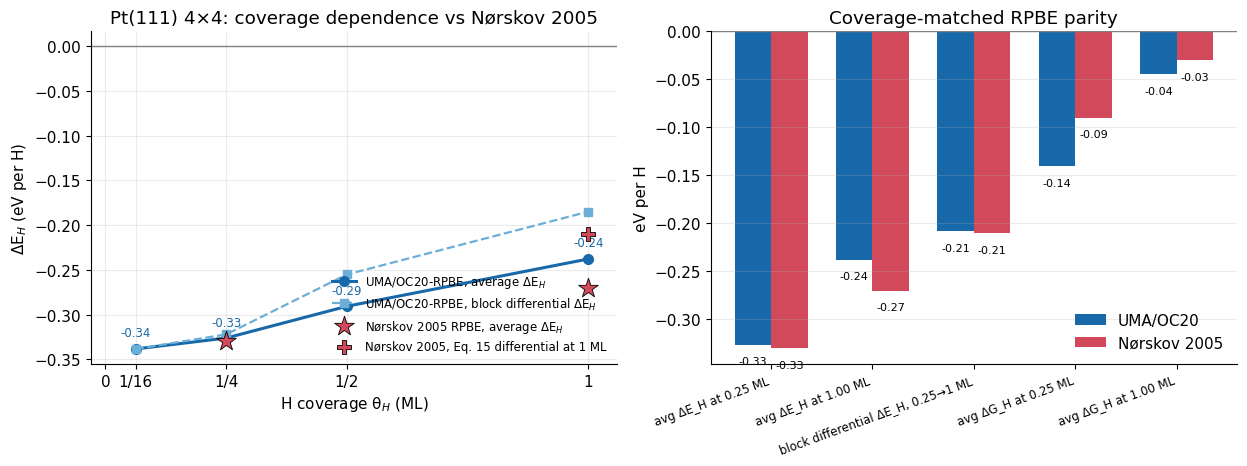

In [17]:
figure_dir = OUT_ROOT / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))
ax = axes[0]
ax.plot(energy_table["coverage_ML"], energy_table["delta_E_H_average_eV_per_H"], "o-", lw=2.2, ms=7, color="#1769aa",
        label="UMA/OC20-RPBE, average ΔE$_H$")
ax.plot(energy_table["coverage_ML"], energy_table["delta_E_H_step_eV_per_H"], "s--", lw=1.6, ms=6, color="#6baed6",
        label="UMA/OC20-RPBE, block differential ΔE$_H$")
ax.scatter(literature_coverage["coverage_ML"], literature_coverage["delta_E_average_eV_per_H"], marker="*", s=220,
           color="#d1495b", edgecolor="black", linewidth=0.6, zorder=5, label="Nørskov 2005 RPBE, average ΔE$_H$")
ax.scatter([1.0], [literature_diff_E_1ML], marker="P", s=110, color="#d1495b", edgecolor="black", linewidth=0.6, zorder=5,
           label="Nørskov 2005, Eq. 15 differential at 1 ML")
for _, r in energy_table.iterrows():
    ax.annotate(f"{r['delta_E_H_average_eV_per_H']:+.2f}", (r["coverage_ML"], r["delta_E_H_average_eV_per_H"]),
                xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8.5, color="#1769aa")
ax.axhline(0, color="0.5", lw=1)
ax.set_xticks([0, 1/16, 0.25, 0.5, 1.0], ["0", "1/16", "1/4", "1/2", "1"])
ax.set_xlim(-0.03, 1.06)
ax.set_xlabel("H coverage θ$_H$ (ML)"); ax.set_ylabel("ΔE$_H$ (eV per H)")
ax.set_title("Pt(111) 4×4: coverage dependence vs Nørskov 2005")
ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8.5, loc="lower right")

ax = axes[1]
labels = literature_comparison_table["quantity"].str.replace("average ", "avg ").tolist()
x = np.arange(len(labels)); width = 0.36
ax.bar(x - width/2, literature_comparison_table["UMA_OC20_RPBE_eV_per_H"], width, color="#1769aa", label="UMA/OC20")
ax.bar(x + width/2, literature_comparison_table["literature_RPBE_eV_per_H"], width, color="#d1495b", label="Nørskov 2005")
for xpos, value in zip(np.r_[x - width/2, x + width/2],
                       np.r_[literature_comparison_table["UMA_OC20_RPBE_eV_per_H"], literature_comparison_table["literature_RPBE_eV_per_H"]]):
    ax.text(xpos, value + (0.012 if value >= 0 else -0.012), f"{value:+.2f}", ha="center",
            va="bottom" if value >= 0 else "top", fontsize=8)
ax.axhline(0, color="0.5", lw=1)
ax.set_xticks(x, labels, rotation=20, ha="right", fontsize=8.5)
ax.set_ylabel("eV per H"); ax.set_title("Coverage-matched RPBE parity")
ax.grid(axis="y", alpha=0.25); ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(figure_dir / "Pt111_coverage_vs_Norskov.png", dpi=240, bbox_inches="tight")
plt.show()

## 14) Nørskov-style 12-metal benchmark with UMA

Your comparison table (Nørskov DFT, EquiformerV2 ML-adsorption energies, single-point DFT, exchange-current densities) is entered below. For each MP-ID the RPBE-relaxed bulk record is taken from the OC20 database, its conventional lattice parameters are extracted, and the Nørskov geometry is rebuilt: **2×2, three-layer close-packed slab, one H (0.25 ML), only the top layer and H relaxed.** The close-packed plane is chosen from the detected lattice: fcc→(111), bcc→(110), hcp→(0001). H is relaxed from every high-symmetry site; the table reports both the fcc/hollow-site value (Nørskov's site) and the global minimum with its geometrically classified site.

Caveats: (i) the OC20 task has no explicit spin input, so Ni/Co magnetism is implicit in the model; (ii) `mp-102` is fcc Co and `mp-8642` is hcp Re, so "Re(111)" in the table corresponds to Re(0001); (iii) the Pt exchange current in your table (−2.63) differs from the value used in the earlier volcano (−3.1) — the table value is used here, so check the citation you intend to keep.

In [19]:
NORSKOV_SET = pd.DataFrame([
    # mp_id, symbol, slab label, expected lattice, Nørskov DFT, EquiformerV2, SP-DFT, log10(i0 / A cm^-2)
    ("mp-81",   "Au", "Au(111)", "fcc",  0.21,  0.23,  0.35, -6.60),
    ("mp-124",  "Ag", "Ag(111)", "fcc",  0.27,  0.30,  0.39, -5.00),
    ("mp-2",    "Pd", "Pd(111)", "fcc", -0.38, -0.47, -0.49, -3.00),
    ("mp-126",  "Pt", "Pt(111)", "fcc", -0.33, -0.37, -0.40, -2.63),
    ("mp-74",   "Rh", "Rh(111)", "fcc", -0.34, -0.39, -0.39, -3.60),
    ("mp-101",  "Ir", "Ir(111)", "fcc", -0.21, -0.37, -0.35, -3.70),
    ("mp-23",   "Ni", "Ni(111)", "fcc", -0.51, -0.53, -0.53, -5.20),
    ("mp-91",   "W",  "W(110)",  "bcc", -0.67, -0.66, -0.64, -5.90),
    ("mp-102",  "Co", "Co(111)", "fcc", -0.51, -0.51, -0.52, -5.32),
    ("mp-30",   "Cu", "Cu(111)", "fcc", -0.05, -0.10, -0.10, -5.37),
    ("mp-129",  "Mo", "Mo(110)", "bcc", -0.61, -0.61, -0.61, -7.07),
    ("mp-8642", "Re", "Re(111)", "hcp", -0.56, -0.60, -0.55, -2.87),
], columns=["mp_id", "symbol", "slab", "expected_lattice", "dE_Norskov_DFT_eV", "dE_EquiformerV2_eV",
            "dE_SP_DFT_eV", "log10_i0_A_cm2"])

from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

SPACEGROUP_TO_LATTICE = {225: "fcc", 229: "bcc", 194: "hcp"}
SURFACE_BUILDERS = {"fcc": ("111", fcc111, ("fcc", "hcp", "bridge", "ontop"), "fcc"),
                    "hcp": ("0001", hcp0001, ("fcc", "hcp", "bridge", "ontop"), "fcc"),
                    "bcc": ("110", bcc110, ("hollow", "longbridge", "shortbridge", "ontop"), "hollow")}
norskov_dir = OUT_ROOT / "03_Norskov_2x2_benchmark"
norskov_dir.mkdir(parents=True, exist_ok=True)

SYMPREC_LADDER = (1e-2, 5e-2, 1e-1, 2e-1)

def lattice_from_volume(record, lattice):
    # Fallback lattice parameters that do not rely on symmetry detection.
    v_atom = float(record.get_volume() / len(record))
    if lattice == "fcc":
        return (4.0 * v_atom) ** (1.0 / 3.0), np.nan
    if lattice == "bcc":
        return (2.0 * v_atom) ** (1.0 / 3.0), np.nan
    # hcp: a = shortest interatomic distance; c from V_atom = (sqrt(3)/4) a^2 c
    dm = record.get_all_distances(mic=True) if len(record) > 1 else None
    a = float(np.min(dm[np.triu_indices(len(record), 1)])) if dm is not None else min(record.cell.lengths()[:2])
    return a, 4.0 * v_atom / (np.sqrt(3.0) * a * a)

def lattice_from_oc20_record(mp_id, symbol, expected):
    try:
        record = Bulk(bulk_src_id_from_db=mp_id).atoms.copy()
        source = f"OC20 RPBE bulk {mp_id}"
    except Exception as exc:
        print(f"WARNING {mp_id} ({symbol}): not found in the OC20 bulk database ({exc}); using ASE reference lattice.")
        record = ase_bulk(symbol, expected); source = "ASE reference lattice (fallback)"
    assert set(record.get_chemical_symbols()) == {symbol}, f"{mp_id} is not elemental {symbol}: {record.get_chemical_formula()}"
    structure = AseAtomsAdaptor.get_structure(record)

    # 1) Symmetry detection with a tolerance ladder (OC20 relaxations can leave small distortions).
    lattice, spg, sga_used, symprec_used = None, None, None, None
    for symprec in SYMPREC_LADDER:
        sga = SpacegroupAnalyzer(structure, symprec=symprec)
        spg_try = sga.get_space_group_number()
        if spg is None:
            spg = spg_try   # strict-tolerance space group, kept for the record
        if spg_try in SPACEGROUP_TO_LATTICE:
            lattice, sga_used, symprec_used = SPACEGROUP_TO_LATTICE[spg_try], sga, symprec
            spg = spg_try
            break

    # 2) Fallback: keep the table's lattice type and derive a (and c) from the cell volume.
    if lattice is None:
        cellpar = np.round(record.cell.cellpar(), 3)
        print(f"WARNING {mp_id} ({symbol}): strict space group {spg} (cell {cellpar.tolist()}) is not fcc/bcc/hcp even at "
              f"symprec={SYMPREC_LADDER[-1]}; treating it as the expected '{expected}' lattice with a from volume per atom.")
        lattice = expected
        a, c = lattice_from_volume(record, lattice)
        method = "volume-per-atom fallback"
    else:
        if lattice != expected:
            print(f"WARNING {mp_id} ({symbol}): detected {lattice} (SG {spg}) but the table expected {expected}; using {lattice}.")
        conventional = sga_used.get_conventional_standard_structure()
        a, c = float(conventional.lattice.a), float(conventional.lattice.c)
        method = f"conventional cell, symprec={symprec_used}"
        # Sanity check: the symmetrized conventional a must agree with the volume-derived a.
        a_vol, _ = lattice_from_volume(record, lattice)
        if abs(a - a_vol) > 0.02:
            print(f"WARNING {mp_id} ({symbol}): conventional a={a:.4f} Å differs from volume-derived a={a_vol:.4f} Å; using volume-derived.")
            a, c = a_vol, (c if lattice == "hcp" else np.nan)
    return {"lattice": lattice, "spacegroup": spg, "a_A": float(a), "c_A": float(c) if lattice == "hcp" else np.nan,
            "lattice_source": source, "lattice_method": method}

def build_norskov_slab(symbol, lattice, a, c):
    miller, builder, sites, norskov_site = SURFACE_BUILDERS[lattice]
    kwargs = {"a": a, "c": c} if lattice == "hcp" else {"a": a}
    slab = builder(symbol, size=NORSKOV_SIZE, vacuum=NORSKOV_VACUUM, periodic=True, **kwargs)
    slab.set_array("layer_id", slab.get_tags().copy())
    oc_tags = np.ones(len(slab), dtype=int)
    oc_tags[slab.arrays["layer_id"] > (NORSKOV_SIZE[2] - NORSKOV_FIXED_BOTTOM_LAYERS)] = 0
    slab.set_tags(oc_tags)
    return slab, miller, sites, norskov_site

def norskov_relax(atoms, stem):
    return relax_atoms(atoms, norskov_dir / f"{stem}.traj", norskov_dir / f"{stem}.log",
                       n_layers=NORSKOV_SIZE[2], n_fixed=NORSKOV_FIXED_BOTTOM_LAYERS)

norskov_rows, norskov_site_rows, norskov_structures = [], [], {}
if RUN_NORSKOV_SET:
    for _, entry in NORSKOV_SET.iterrows():
        symbol, mp_id = entry["symbol"], entry["mp_id"]
        lat = lattice_from_oc20_record(mp_id, symbol, entry["expected_lattice"])
        clean, miller, sites, norskov_site = build_norskov_slab(symbol, lat["lattice"], lat["a_A"], lat["c_A"])
        n_top = len(metal_indices_in_layer(clean, 1)); assert n_top == 4, f"{symbol}: expected 4 top atoms, got {n_top}"
        clean_relaxed, e_clean, ok_clean, _ = norskov_relax(clean, f"{symbol}_{miller}_clean")
        nn = surface_nn_distance(clean_relaxed)

        # Ideal-site catalogue on the relaxed clean slab (used for bcc(110) classification).
        cat_pos, cat_lab = [], []
        for site in sites:
            probe = clean_relaxed.copy(); add_H_at_site(probe, site, (0, 0))
            cat_pos.append(probe.positions[-1].copy()); cat_lab.append(site)
        cat_pos = np.array(cat_pos)

        best = None
        for site in sites:
            adslab = clean_relaxed.copy(); add_H_at_site(adslab, site, (0, 0))
            relaxed, e_ads, ok, fmax = norskov_relax(adslab, f"{symbol}_{miller}_H_{site}")
            h_id = h_indices(relaxed)[0]
            if lat["lattice"] == "bcc":
                final_site = classify_H_site_by_catalogue(relaxed, h_id, cat_pos, cat_lab, tol_A=0.5 * nn)["site"]
            else:
                final_site = classify_H_site_geometric(relaxed, h_id, nn)["site"]
            dE = e_ads - e_clean - E_H_REF
            row = {"mp_id": mp_id, "symbol": symbol, "surface": f"{symbol}({miller})", "initial_site": site,
                   "final_site": final_site, "dE_H_UMA_eV": dE, "converged": ok and ok_clean, "max_force": fmax,
                   "E_clean_eV": e_clean, "E_ads_eV": e_ads}
            norskov_site_rows.append(row)
            if best is None or (row["converged"] and dE < best["dE_H_UMA_eV"]):
                best = {**row, "atoms": relaxed}
        norskov_structures[symbol] = best["atoms"]
        site_matched = [r for r in norskov_site_rows if r["symbol"] == symbol and r["initial_site"] == norskov_site][0]
        norskov_rows.append({**entry.to_dict(), "surface": best["surface"], "lattice": lat["lattice"],
                             "spacegroup": lat["spacegroup"], "a_A": lat["a_A"], "c_A": lat["c_A"],
                             "lattice_source": lat["lattice_source"], "lattice_method": lat["lattice_method"], "d_NN_A": nn,
                             "Norskov_site": norskov_site, "dE_UMA_Norskov_site_eV": site_matched["dE_H_UMA_eV"],
                             "dE_UMA_min_eV": best["dE_H_UMA_eV"], "UMA_min_site": best["final_site"],
                             "UMA_min_initial_site": best["initial_site"], "all_converged": all(
                                 r["converged"] for r in norskov_site_rows if r["symbol"] == symbol)})
        print(f"{best['surface']:<8s} {lat['lattice']} a={lat['a_A']:.3f} Å | UMA min ΔE_H = {best['dE_H_UMA_eV']:+.3f} eV "
              f"({best['final_site']}) | fcc/hollow-site = {site_matched['dE_H_UMA_eV']:+.3f} eV | Nørskov {entry['dE_Norskov_DFT_eV']:+.2f}")

    norskov_table = pd.DataFrame(norskov_rows)
    norskov_table.to_csv(norskov_dir / "Norskov_2x2_UMA_benchmark.csv", index=False)
    pd.DataFrame(norskov_site_rows).to_csv(norskov_dir / "Norskov_2x2_UMA_all_sites.csv", index=False)

    def mae(col):
        return float((norskov_table[col] - norskov_table["dE_Norskov_DFT_eV"]).abs().mean())
    error_table = pd.DataFrame({
        "method": ["EquiformerV2 (your table)", "SP-DFT (your table)", "UMA/OC20, Nørskov site", "UMA/OC20, global minimum"],
        "MAE_vs_Norskov_eV": [mae("dE_EquiformerV2_eV"), mae("dE_SP_DFT_eV"), mae("dE_UMA_Norskov_site_eV"), mae("dE_UMA_min_eV")],
        "max_abs_error_eV": [float((norskov_table[c] - norskov_table["dE_Norskov_DFT_eV"]).abs().max())
                             for c in ("dE_EquiformerV2_eV", "dE_SP_DFT_eV", "dE_UMA_Norskov_site_eV", "dE_UMA_min_eV")]})
    error_table.to_csv(norskov_dir / "error_vs_Norskov.csv", index=False)
    display(norskov_table[["mp_id", "surface", "lattice", "a_A", "dE_Norskov_DFT_eV", "dE_EquiformerV2_eV", "dE_SP_DFT_eV",
                           "Norskov_site", "dE_UMA_Norskov_site_eV", "dE_UMA_min_eV", "UMA_min_site", "log10_i0_A_cm2", "all_converged"]]
            .style.format({"a_A": "{:.3f}", "dE_Norskov_DFT_eV": "{:+.2f}", "dE_EquiformerV2_eV": "{:+.2f}", "dE_SP_DFT_eV": "{:+.2f}",
                           "dE_UMA_Norskov_site_eV": "{:+.3f}", "dE_UMA_min_eV": "{:+.3f}", "log10_i0_A_cm2": "{:.2f}"}))
    display(error_table.style.format({"MAE_vs_Norskov_eV": "{:.3f}", "max_abs_error_eV": "{:.3f}"}))
else:
    norskov_table = None
    print("Nørskov 12-metal benchmark skipped (RUN_NORSKOV_SET=False).")

Au(111)  fcc a=4.196 Å | UMA min ΔE_H = +0.255 eV (fcc) | fcc/hollow-site = +0.255 eV | Nørskov +0.21
Ag(111)  fcc a=4.210 Å | UMA min ΔE_H = +0.350 eV (hcp) | fcc/hollow-site = +0.350 eV | Nørskov +0.27
Pd(111)  fcc a=3.978 Å | UMA min ΔE_H = -0.426 eV (fcc) | fcc/hollow-site = -0.426 eV | Nørskov -0.38
Pt(111)  fcc a=3.990 Å | UMA min ΔE_H = -0.405 eV (ontop) | fcc/hollow-site = -0.354 eV | Nørskov -0.33
Rh(111)  fcc a=3.847 Å | UMA min ΔE_H = -0.324 eV (fcc) | fcc/hollow-site = -0.324 eV | Nørskov -0.34
Ir(111)  fcc a=3.887 Å | UMA min ΔE_H = -0.344 eV (ontop) | fcc/hollow-site = -0.206 eV | Nørskov -0.21
Ni(111)  fcc a=3.545 Å | UMA min ΔE_H = -0.516 eV (fcc) | fcc/hollow-site = -0.516 eV | Nørskov -0.51
W(110)   bcc a=3.181 Å | UMA min ΔE_H = -0.656 eV (hollow) | fcc/hollow-site = -0.656 eV | Nørskov -0.67
Co(111)  fcc a=3.478 Å | UMA min ΔE_H = -0.471 eV (fcc) | fcc/hollow-site = -0.471 eV | Nørskov -0.51
Cu(111)  fcc a=3.677 Å | UMA min ΔE_H = -0.031 eV (fcc) | fcc/hollow-site =

,mp_id,surface,lattice,a_A,dE_Norskov_DFT_eV,dE_EquiformerV2_eV,dE_SP_DFT_eV,Norskov_site,dE_UMA_Norskov_site_eV,dE_UMA_min_eV,UMA_min_site,log10_i0_A_cm2,all_converged
0,mp-81,Au(111),fcc,4.196,+0.21,+0.23,+0.35,fcc,+0.255,+0.255,fcc,-6.60,True
1,mp-124,Ag(111),fcc,4.210,+0.27,+0.30,+0.39,fcc,+0.350,+0.350,hcp,-5.00,True
2,mp-2,Pd(111),fcc,3.978,-0.38,-0.47,-0.49,fcc,-0.426,-0.426,fcc,-3.00,True
3,mp-126,Pt(111),fcc,3.990,-0.33,-0.37,-0.40,fcc,-0.354,-0.405,ontop,-2.63,True
4,mp-74,Rh(111),fcc,3.847,-0.34,-0.39,-0.39,fcc,-0.324,-0.324,fcc,-3.60,True
5,mp-101,Ir(111),fcc,3.887,-0.21,-0.37,-0.35,fcc,-0.206,-0.344,ontop,-3.70,True
6,mp-23,Ni(111),fcc,3.545,-0.51,-0.53,-0.53,fcc,-0.516,-0.516,fcc,-5.20,True
7,mp-91,W(110),bcc,3.181,-0.67,-0.66,-0.64,hollow,-0.656,-0.656,hollow,-5.90,True
8,mp-102,Co(111),fcc,3.478,-0.51,-0.51,-0.52,fcc,-0.471,-0.471,fcc,-5.32,True
9,mp-30,Cu(111),fcc,3.677,-0.05,-0.10,-0.10,fcc,-0.031,-0.031,fcc,-5.37,True


,method,MAE_vs_Norskov_eV,max_abs_error_eV
0,EquiformerV2 (your table),0.042,0.160
1,SP-DFT (your table),0.063,0.140
2,"UMA/OC20, Nørskov site",0.028,0.080
3,"UMA/OC20, global minimum",0.042,0.134


### Parity, per-metal, and volcano figures for the 12-metal set

The Pt(111) 4×4 values at 0.25 ML and 1 ML are overlaid on the volcano as vertical markers — no exchange current is inferred from UMA.

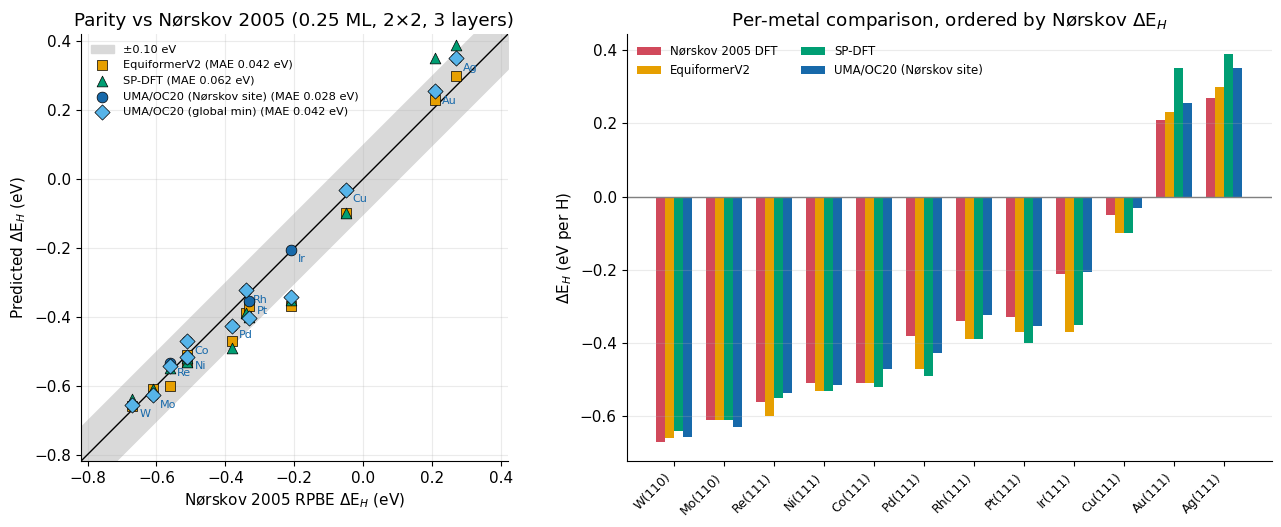

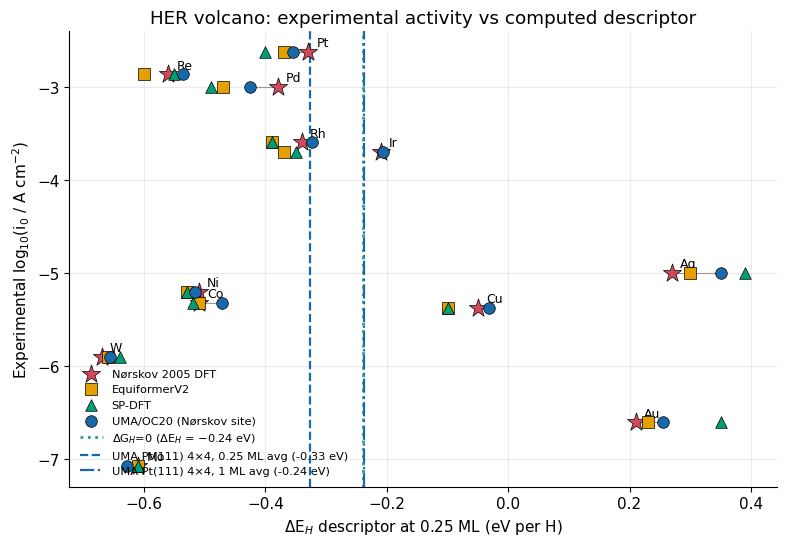

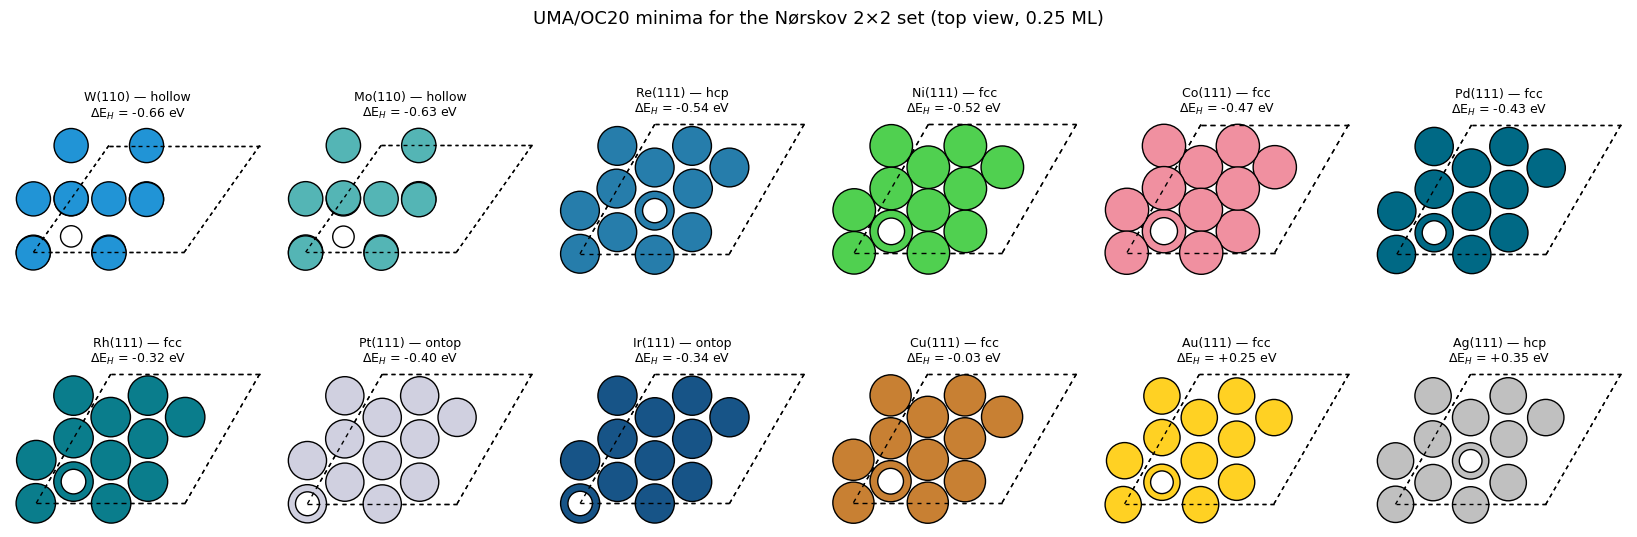

In [20]:
if norskov_table is not None:
    methods = [("dE_EquiformerV2_eV", "EquiformerV2", "#e69f00", "s"),
               ("dE_SP_DFT_eV", "SP-DFT", "#009e73", "^"),
               ("dE_UMA_Norskov_site_eV", "UMA/OC20 (Nørskov site)", "#1769aa", "o"),
               ("dE_UMA_min_eV", "UMA/OC20 (global min)", "#56b4e9", "D")]
    tbl = norskov_table.sort_values("dE_Norskov_DFT_eV").reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4), gridspec_kw={"width_ratios": [1, 1.35]})
    ax = axes[0]
    lo, hi = tbl["dE_Norskov_DFT_eV"].min() - 0.15, tbl["dE_Norskov_DFT_eV"].max() + 0.15
    ax.plot([lo, hi], [lo, hi], "k-", lw=1); ax.fill_between([lo, hi], [lo-0.1, hi-0.1], [lo+0.1, hi+0.1], color="0.85", label="±0.10 eV")
    for col, name, color, marker in methods:
        m = float((tbl[col] - tbl["dE_Norskov_DFT_eV"]).abs().mean())
        ax.scatter(tbl["dE_Norskov_DFT_eV"], tbl[col], s=60, marker=marker, color=color, edgecolor="black", linewidth=0.5,
                   label=f"{name} (MAE {m:.3f} eV)", zorder=4)
    for _, r in tbl.iterrows():
        ax.annotate(r["symbol"], (r["dE_Norskov_DFT_eV"], r["dE_UMA_Norskov_site_eV"]), xytext=(5, -9), textcoords="offset points", fontsize=8, color="#1769aa")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel("Nørskov 2005 RPBE ΔE$_H$ (eV)"); ax.set_ylabel("Predicted ΔE$_H$ (eV)")
    ax.set_title("Parity vs Nørskov 2005 (0.25 ML, 2×2, 3 layers)"); ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8.2, loc="upper left")

    ax = axes[1]
    x = np.arange(len(tbl)); width = 0.18
    ax.bar(x - 1.5*width, tbl["dE_Norskov_DFT_eV"], width, color="#d1495b", label="Nørskov 2005 DFT")
    for k, (col, name, color, _) in enumerate(methods[:3]):
        ax.bar(x + (k - 0.5) * width, tbl[col], width, color=color, label=name)
    ax.axhline(0, color="0.5", lw=1)
    ax.set_xticks(x, tbl["surface"], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("ΔE$_H$ (eV per H)"); ax.set_title("Per-metal comparison, ordered by Nørskov ΔE$_H$")
    ax.grid(axis="y", alpha=0.25); ax.legend(frameon=False, fontsize=8.5, ncol=2)
    fig.tight_layout(); fig.savefig(figure_dir / "Norskov_set_parity_and_bars.png", dpi=240, bbox_inches="tight"); plt.show()

    # HER volcano: log10(i0) vs descriptor, one marker style per descriptor source.
    fig, ax = plt.subplots(figsize=(8.0, 5.6))
    sources = [("dE_Norskov_DFT_eV", "Nørskov 2005 DFT", "#d1495b", "*", 190)] + [(c, n, col, m, 70) for c, n, col, m in methods[:3]]
    for col, name, color, marker, size in sources:
        ax.scatter(tbl[col], tbl["log10_i0_A_cm2"], s=size, marker=marker, color=color, edgecolor="black", linewidth=0.5, label=name, zorder=4)
    for _, r in tbl.iterrows():
        ax.annotate(r["symbol"], (r["dE_Norskov_DFT_eV"], r["log10_i0_A_cm2"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
        ax.plot([r["dE_Norskov_DFT_eV"], r["dE_UMA_Norskov_site_eV"]], [r["log10_i0_A_cm2"]] * 2, color="0.6", lw=0.8, zorder=2)
    ax.axvline(-0.24, color="#2a9d8f", ls=":", lw=2, label="ΔG$_H$=0 (ΔE$_H$ = −0.24 eV)")
    pt_025 = float(model_025["delta_E_H_average_eV_per_H"]); pt_100 = float(model_100["delta_E_H_average_eV_per_H"])
    ax.axvline(pt_025, color="#1769aa", ls="--", lw=1.6, label=f"UMA Pt(111) 4×4, 0.25 ML avg ({pt_025:+.2f} eV)")
    ax.axvline(pt_100, color="#1769aa", ls="-.", lw=1.6, label=f"UMA Pt(111) 4×4, 1 ML avg ({pt_100:+.2f} eV)")
    ax.set_xlabel("ΔE$_H$ descriptor at 0.25 ML (eV per H)"); ax.set_ylabel("Experimental log$_{10}$(i$_0$ / A cm$^{-2}$)")
    ax.set_title("HER volcano: experimental activity vs computed descriptor"); ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8.2, loc="lower left")
    fig.tight_layout(); fig.savefig(figure_dir / "HER_volcano_Norskov_set.png", dpi=240, bbox_inches="tight"); plt.show()

    # Static structure gallery of the UMA minima for the 12 metals.
    fig, axes = plt.subplots(2, 6, figsize=(16.5, 6.2))
    for ax, (_, r) in zip(axes.ravel(), tbl.iterrows()):
        atoms = norskov_structures[r["symbol"]]
        radii = np.where(np.array(atoms.get_chemical_symbols()) == "H", 0.45, 0.72)
        plot_atoms(atoms, ax, rotation="0x,0y,0z", show_unit_cell=2, radii=radii)
        ax.set_title(f"{r['surface']} — {r['UMA_min_site']}\nΔE$_H$ = {r['dE_UMA_min_eV']:+.2f} eV", fontsize=9); ax.set_axis_off()
    fig.suptitle("UMA/OC20 minima for the Nørskov 2×2 set (top view, 0.25 ML)", fontsize=13)
    fig.tight_layout(); fig.savefig(figure_dir / "Norskov_set_structures_top_view.png", dpi=240, bbox_inches="tight", facecolor="white"); plt.show()

## 15) Screening-funnel and thermochemistry figures

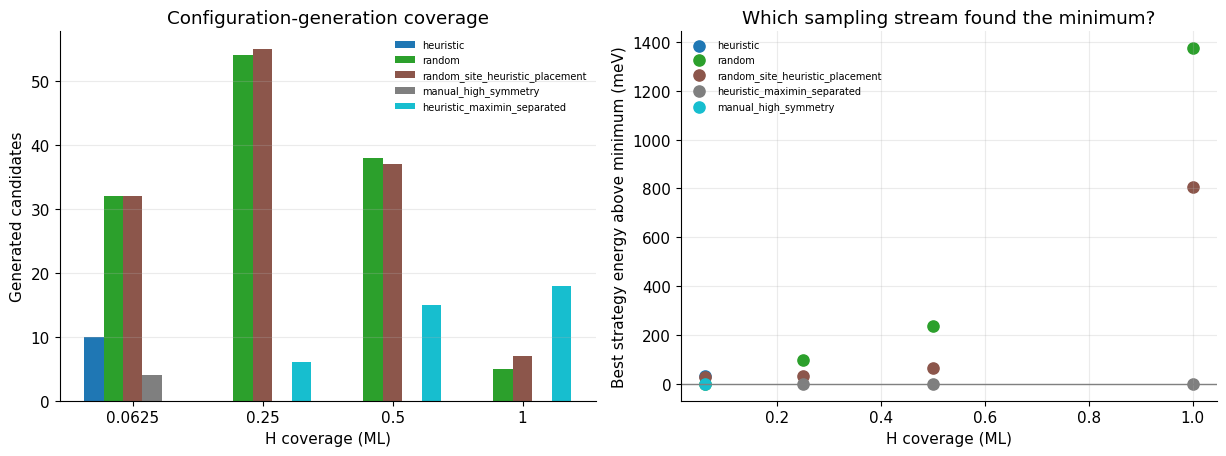

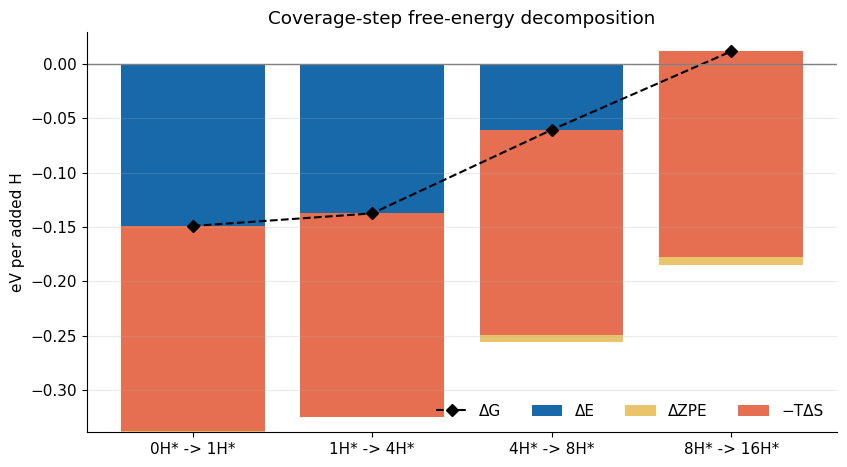

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.7))
generated_counts = candidate_inventory.groupby(["coverage_ML", "sampling_strategy"]).size().rename("count").reset_index()
strategies = list(generated_counts["sampling_strategy"].unique())
coverages = sorted(generated_counts["coverage_ML"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(strategies)))
width = 0.75 / len(strategies); x = np.arange(len(coverages))
for k, (strategy, color) in enumerate(zip(strategies, colors)):
    values = [int(m["count"].iloc[0]) if len(m := generated_counts[np.isclose(generated_counts["coverage_ML"], cov)
              & (generated_counts["sampling_strategy"] == strategy)]) else 0 for cov in coverages]
    axes[0].bar(x + (k - (len(strategies)-1)/2)*width, values, width, label=strategy.replace("fairchem_", ""), color=color)
axes[0].set_xticks(x, [f"{c:.4g}" for c in coverages]); axes[0].set_xlabel("H coverage (ML)")
axes[0].set_ylabel("Generated candidates"); axes[0].set_title("Configuration-generation coverage")
axes[0].grid(axis="y", alpha=0.25); axes[0].legend(frameon=False, fontsize=7)
for k, (strategy, group) in enumerate(strategy_minima_table.groupby("sampling_strategy")):
    axes[1].scatter(group["coverage_ML"], 1000 * group["energy_above_coverage_minimum_eV"], s=65,
                    label=strategy.replace("fairchem_", ""), color=colors[k % len(colors)])
axes[1].axhline(0, color="0.5", lw=1); axes[1].set_xlabel("H coverage (ML)")
axes[1].set_ylabel("Best strategy energy above minimum (meV)"); axes[1].set_title("Which sampling stream found the minimum?")
axes[1].grid(alpha=0.25); axes[1].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(figure_dir / "configuration_screening_funnel.png", dpi=240, bbox_inches="tight"); plt.show()

if free_energy_table is not None:
    labels = free_energy_table["transition"].tolist(); x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    e_part = free_energy_table["delta_E_H_step_eV_per_H"].to_numpy()
    zpe_part = free_energy_table["delta_ZPE_step_eV_per_H"].to_numpy()
    entropy_part = free_energy_table["minus_T_delta_S_step_eV_per_H"].to_numpy()
    ax.bar(x, e_part, label="ΔE", color="#1769aa"); ax.bar(x, zpe_part, bottom=e_part, label="ΔZPE", color="#e9c46a")
    ax.bar(x, entropy_part, bottom=e_part + zpe_part, label="−TΔS", color="#e76f51")
    ax.plot(x, free_energy_table["delta_G_H_step_eV_per_H"], "kD--", label="ΔG")
    ax.axhline(0, color="0.5", lw=1); ax.set_xticks(x, labels); ax.set_ylabel("eV per added H")
    ax.set_title("Coverage-step free-energy decomposition"); ax.grid(axis="y", alpha=0.25); ax.legend(frameon=False, ncol=4)
    fig.tight_layout(); fig.savefig(figure_dir / "thermochemistry_decomposition.png", dpi=240, bbox_inches="tight"); plt.show()

## 16) Electronic and thermodynamic coverage-step descriptors

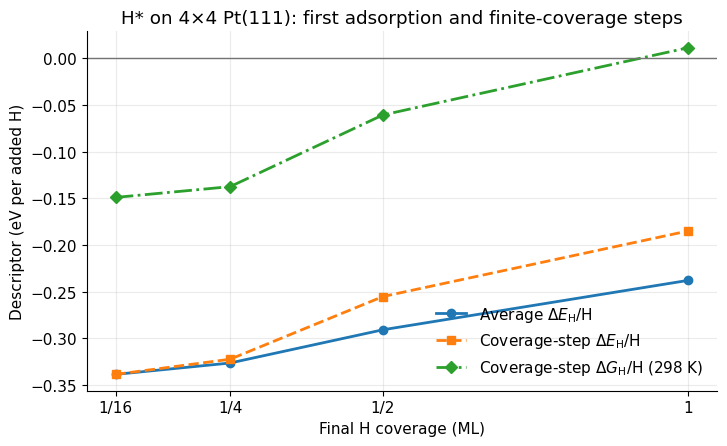

In [22]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(energy_table["coverage_ML"], energy_table["delta_E_H_average_eV_per_H"], "o-", lw=2, label=r"Average $\Delta E_\mathrm{H}$/H")
ax.plot(energy_table["coverage_ML"], energy_table["delta_E_H_step_eV_per_H"], "s--", lw=2, label=r"Coverage-step $\Delta E_\mathrm{H}$/H")
if free_energy_table is not None:
    ax.plot(free_energy_table["coverage_ML"], free_energy_table["delta_G_H_step_eV_per_H"], "D-.", lw=2,
            label=rf"Coverage-step $\Delta G_\mathrm{{H}}$/H ({TEMPERATURE_K:.0f} K)")
ax.axhline(0.0, color="0.45", lw=1)
ax.set_xticks([1/16, 0.25, 0.50, 1.0], ["1/16", "1/4", "1/2", "1"])
ax.set_xlabel("Final H coverage (ML)"); ax.set_ylabel("Descriptor (eV per added H)")
ax.set_title("H* on 4×4 Pt(111): first adsorption and finite-coverage steps")
ax.grid(alpha=0.25); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(figure_dir / "coverage_deltaE_deltaG.png", dpi=240, bbox_inches="tight"); plt.show()

## 17) Static structure visualization

Titles now read *top view* / *side view* and list the geometrically classified site(s). H atoms are drawn larger so they are visible against Pt.

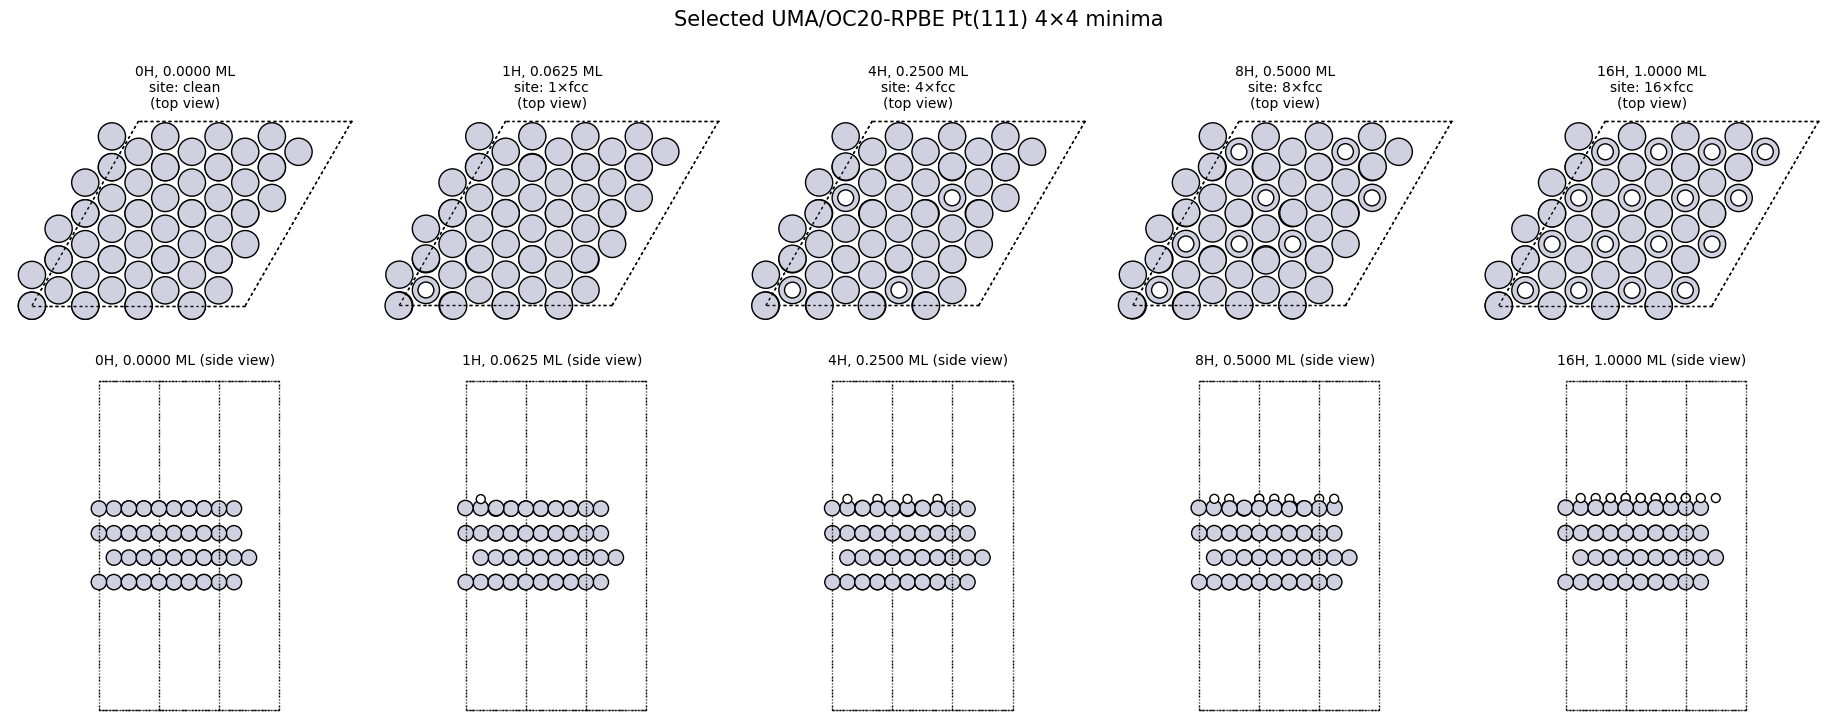

,N_H,coverage_ML,site_summary,configuration_seed
0,0,0.0000,clean,clean
1,1,0.0625,1×fcc,fcc_00
2,4,0.2500,4×fcc,fcc_00__fcc_02__fcc_20__fcc_22
3,8,0.5000,8×fcc,fcc_00__fcc_01__fcc_03__fcc_11__fcc_12__fcc_21...
4,16,1.0000,16×fcc,fcc_00__fcc_01__fcc_02__fcc_03__fcc_10__fcc_11...


In [23]:
states_to_plot = list(sampled_states)
fig, axes = plt.subplots(2, len(states_to_plot), figsize=(3.7 * len(states_to_plot), 7.4))
for column, n_h in enumerate(states_to_plot):
    atoms = minima[n_h]["atoms"]; coverage = minima[n_h]["coverage_ML"]; sites = minima[n_h]["site_summary"]
    radii = np.where(np.array(atoms.get_chemical_symbols()) == "H", 0.42, 0.72)
    plot_atoms(atoms, axes[0, column], rotation="0x,0y,0z", show_unit_cell=2, radii=radii)
    axes[0, column].set_title(f"{n_h}H, {coverage:.4f} ML\nsite: {sites}\n(top view)", fontsize=10); axes[0, column].set_axis_off()
    plot_atoms(atoms, axes[1, column], rotation="-90x,0y,0z", show_unit_cell=2, radii=radii)
    axes[1, column].set_title(f"{n_h}H, {coverage:.4f} ML (side view)", fontsize=10); axes[1, column].set_axis_off()
fig.suptitle("Selected UMA/OC20-RPBE Pt(111) 4×4 minima", fontsize=15)
fig.tight_layout(); fig.savefig(figure_dir / "selected_Pt111_structures_static.png", dpi=240, bbox_inches="tight", facecolor="white"); plt.show()

site_report = pd.DataFrame([{"N_H": n, "coverage_ML": minima[n]["coverage_ML"], "site_summary": minima[n]["site_summary"],
                             "configuration_seed": minima[n]["configuration"][:60]} for n in sampled_states])
display(site_report)

## 18) Reporting checklist

- **Surface:** four-layer 4×4 Pt(111), 16 surface Pt atoms; bottom two layers fixed. Lattice from the OC20 RPBE Pt record.
- **Site assignment:** geometric — top-layer neighbour count decides ontop/bridge/hollow; a hollow is *hcp* only if a second-layer atom lies beneath it, otherwise *fcc*. The ideal-site catalogue is verified against this classifier before use.
- **Coverage series:** 1H, 4H, 8H, **16H** (0.0625, 0.25, 0.50, 1.00 ML); 0.25 ML and 1 ML are both coverage-matched to Nørskov 2005.
- **Differential definition:** 0→1H is a true single-H differential; 1→4H, 4→8H, 8→16H are per-H block differentials.
- **Nørskov 12-metal set:** OC20 RPBE bulk records → conventional lattice → 2×2 three-layer close-packed slab (fcc 111 / bcc 110 / hcp 0001), 1 H = 0.25 ML, top layer + H relaxed; every high-symmetry site relaxed; compared with Nørskov DFT, EquiformerV2, and SP-DFT columns; parity, per-metal, and volcano figures exported.
- **Thermochemistry:** H*-state harmonic modes plus H₂ ZPE and ideal-gas entropy.
- **Solvent:** state-level template only; OC20 vacuum energies are never relabelled as solvated.
- **DFT handoff:** RPBE VASP inputs for clean, H₂, 1H, 4H, 8H, 16H; all must be recalculated before combining energies.
- **Audit trail:** generated, prescreened, selected, accepted, rejected, strategy-minimum, Nørskov-set, and error tables are saved under `Pt111_H_4x4_UMA_RPBE_v5/`.